<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [106]:
#!pip install -q gdown torch transformers transformers accelerate bitsandbytes langchain sentence-transformers faiss-gpu openpyxl datasets langchain-community ragatouille umap-learn

In [107]:

# from langchain.docstore.document import Document as LangchainDocument
# from langchain.vectorstores import FAISS
# from langchain_community.embeddings import HuggingFaceEmbeddings
# from langchain_community.vectorstores.utils import DistanceStrategy
# from ragatouille import RAGPretrainedModel
# from sentence_transformers import SentenceTransformer

#------------------------------------------------------------------------------------
# from langchain.text_splitter import ... # выберите другую стратегию разбивки на чанки

# pd.set_option("display.max_colwidth", None)

## Загрузка данных (4 балла)

In [2]:
url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = r'C:\prj\data\points_of_interest\file.csv'

# gdown.download(url, output, quiet=False)

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(output)

In [5]:
df.head()

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14634 entries, 0 to 14633
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   14634 non-null  int64  
 1   Name         14634 non-null  object 
 2   WikiData     12078 non-null  object 
 3   City         14634 non-null  object 
 4   Lon          14634 non-null  float64
 5   Lat          14634 non-null  float64
 6   description  12078 non-null  object 
 7   image        14634 non-null  object 
 8   en_txt       14634 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 1.0+ MB


In [7]:
df.columns

Index(['Unnamed: 0', 'Name', 'WikiData', 'City', 'Lon', 'Lat', 'description',
       'image', 'en_txt'],
      dtype='object')

In [8]:
df.rename(columns={'Unnamed: 0': 'Num'}, inplace=True)

Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [9]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [10]:
def get_image(data):
    image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
    return image

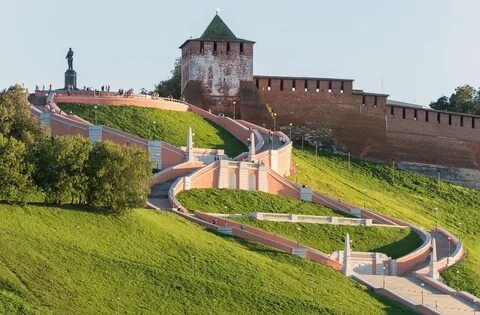

In [11]:
get_image(df.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

In [41]:
CITIES = df.City.unique()
CITIES


array(['Екатеринбург', 'Нижний Новгород', 'Владимир', 'Ярославль'],
      dtype=object)

### Первоначальная очистка

In [12]:
df['description'] = df['description'].fillna('')
df['en_txt'] = df['en_txt'].fillna('')

> Очистим корпус от лишних пробелов

In [13]:
df['description'] = df['description'].str.strip()
df['en_txt'] = df['en_txt'].str.strip()

> Считаем количество пустых записей с описанием

In [14]:
(df['description'] == '').sum()

2556

> Описание фотографий не пустое

In [15]:
(df['en_txt'] == '').sum()

0

In [16]:
print("Найдено записи с пустым описанием (%):  ",
      round((df['description'] == '').sum() / df.shape[0] * 100, 1))

Найдено записи с пустым описанием (%):   17.5


Посмотрим какие параметры пустые при пустом описаниии

In [17]:
df[df['description'] == ''].nunique()

Num            2500
Name             71
WikiData          0
City              2
Lon              74
Lat              73
description       1
image          2404
en_txt         2230
dtype: int64

> Name, City, WikiData разрежены при пустом описании

**Предполагаем что это дополнительные фотографии, ценность которых сомнительна**

Рассмотрим конкретные записи при пустом desc

In [18]:
df[df['description'] == ''][
    ['Name', 'WikiData', 'description', 'en_txt']].sample(10)

,Name,WikiData,description,en_txt
9388,Мальчик с рогаткой,NaN,,two boys are sitting on a fence with a rope
9218,Оборонительный земляной вал древнего Владимира,NaN,,painting of a fence and a gate in a desert area
11308,Дом-музей Максима Богдановича,NaN,,there is a small wooden house with a metal roof
9393,Мальчик с рогаткой,NaN,,arafed boy holding a tennis racket in a field
9718,Памятник Гоголю,NaN,,there is a statue of a man sitting on a pedestal
9783,Макет ракеты-носителя Союз-ТМ,NaN,,a model of a rocket with a red and white strip...
9648,Великая Княгиня Ольга,NaN,,painting of a woman in a white robe and red cape
8131,Кресень,NaN,,a close up of a knife on a wooden table
9109,Дева Мария,NaN,,a painting of a woman holding a child in her arms
9851,Чернобыль - трагедия XX века,NaN,,there are many military vehicles and trucks on...


> Большинство записей имеют не конкретное название

Посмотрим примеры фото по найденным индексам

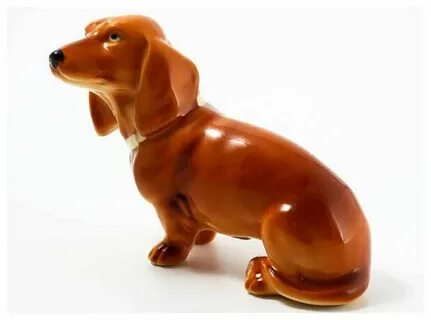

In [19]:
get_image(df.at[9346, 'image'])

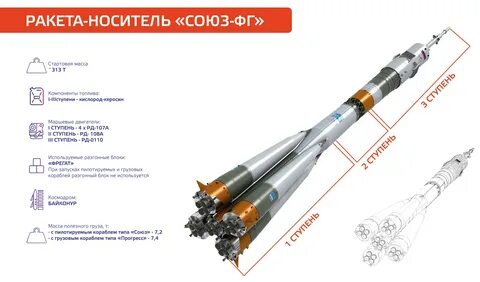

In [20]:
get_image(df.at[9800, 'image'])

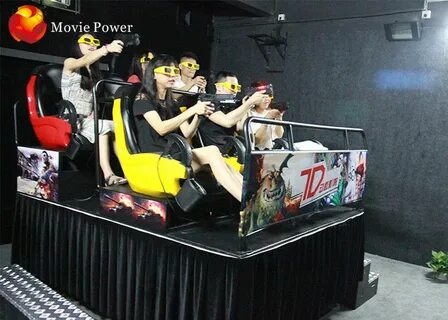

In [21]:
get_image(df.at[9584, 'image'])

> Фото тоже имеет содержание которое слабо относится к достопримечательностям

**Принимаем решение удалить записи с пустым description и WikiData**

In [22]:
df = df[df['description'] != '']

#### Статистика по датасету

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12078 entries, 0 to 14633
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Num          12078 non-null  int64  
 1   Name         12078 non-null  object 
 2   WikiData     12078 non-null  object 
 3   City         12078 non-null  object 
 4   Lon          12078 non-null  float64
 5   Lat          12078 non-null  float64
 6   description  12078 non-null  object 
 7   image        12078 non-null  object 
 8   en_txt       12078 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 943.6+ KB


## EDA разведочный анализ данных

### Поле Num

In [24]:
df.Num.describe()

count    12078.000000
mean      1810.912651
std       1169.944608
min          0.000000
25%        775.250000
50%       1722.500000
75%       2821.000000
max       4371.000000
Name: Num, dtype: float64

In [25]:
df.Num.unique().shape[0]

4372

> На 12 тыс записей имеем всего 4 тыс уникальных значений

Построим распределение по дубликатам

In [53]:
def frequency_distribution(s: pd.Series):
    value_counts = s.value_counts()
    duplicate_counts = value_counts[value_counts > 1]
    plt.figure(figsize=(10, 3))

    frequency_distribution = duplicate_counts.value_counts().sort_index()
    frequency_distribution.plot(kind='bar', color='salmon', edgecolor='grey')
    plt.title('Распределение частоты дубликатов')
    plt.xlabel('Количество повторений')
    plt.ylabel('Количество значений')
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

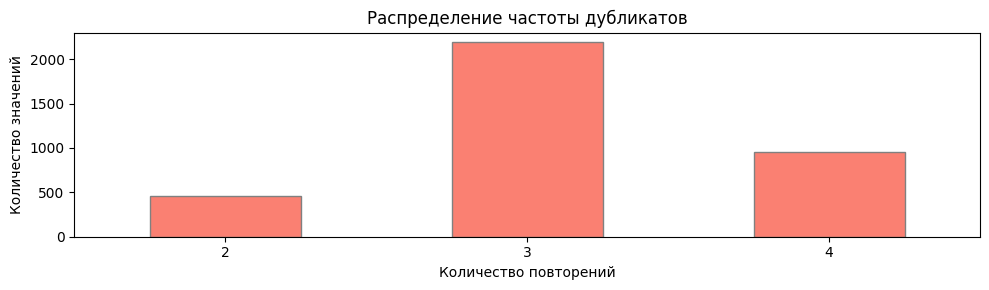

In [54]:
frequency_distribution(df['Num'])

In [45]:
for city in CITIES:
    print(city, df[df.City == city]['Num'].duplicated().sum())

Екатеринбург 0
Нижний Новгород 0
Владимир 0
Ярославль 0


> Получается что Num уникален внутри города.

### Поле Name

In [28]:
df['Name'].unique().shape[0]

317

In [29]:
df['Name'].unique()

array(['Динамо', '№32 Дом обороны', 'Дом обороны',
       '№28 Здание городской электростанции «Луч»',
       '№27 Дом Г.Н. Скрябина', 'Литературная жизнь Урала XX века',
       'Дом-музей Бажова', 'Театр кукол', 'Харитоновский сад',
       'Храм в честь Вознесения Господня', 'Суворовское училище',
       'Свято-Троицкий Кафедральный собор',
       'Дом-музей Д. Н. Мамина-Сибиряка',
       'Художественный Музей Эрнста Неизвестного', 'Серго Орджоникидзе',
       'Н. И. Кузнецову', 'Успенский собор на ВИЗе', 'Царский мост',
       'Дом печати (Екатеринбург)', 'Музей изобразительных искусств',
       'Александро-Невский собор', 'Здание бывшей гостиницы "Мадрид"',
       'Екатеринбургский музей изобразительных искусств',
       'Уральский государственный медицинский университет',
       'Центральный стадион', 'Уральская государственная консерватория',
       '№18 Фотографический музей «Дом Метенкова»',
       'Преображенская церковь на Уктусе',
       'Уральский геологический музей', 'Дом 

#### Типы объектов по содержимому Name

**Выделим внутренние типы объектов**

Сделаем анализ поля Name с помощью LLM:

`Промпт`: Выдели все объекты в городе  наиболее встречаемые. Например,  дом, церковь, башня и т.д.

Выведи в виде списка: ['дома', 'соборы', ... ]

In [48]:
type_freq = ['дом', 'церковь', 'музей', 'памятник', 'собор', 'башня', 'театр',
             'улица', 'парк', 'монастырь', 'усадьба', 'университет', 'мост',
             'храм']

Также выделим редкие объекты но выжные для города

In [49]:
type_rare = ['сад', 'сквер', 'гостиница', 'стадион', 'зоопарк', 'цирк',
             'планетарий']

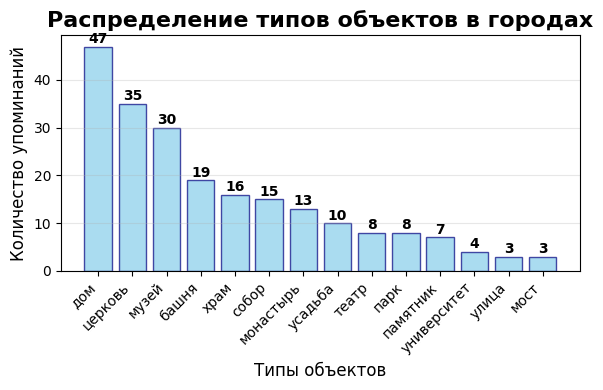

In [50]:
import matplotlib.pyplot as plt
import re

data = df['Name'].unique()


# Функция для поиска вхождений
def count_types_in_data(data, types_list):
    counts = {type_name: 0 for type_name in types_list}
    counts["прочее"] = 0

    for item in data:
        item_lower = item.lower()
        for type_name in types_list:
            # Ищем точные вхождения слов
            if re.search(r'\b' + re.escape(type_name) + r'\b', item_lower):
                counts[type_name] += 1
            else:
                counts["прочее"] += 1

    return counts


# Подсчитываем вхождения
type_counts = count_types_in_data(data, type_freq)
etc_count = type_counts.pop('прочее')

# Сортируем по убыванию частоты
sorted_types = sorted(type_counts.items(), key=lambda x: x[1], reverse=True)
types, counts = zip(*sorted_types)

# Строим график
plt.figure(figsize=(6, 4))
bars = plt.bar(types, counts, color='skyblue', edgecolor='navy', alpha=0.7)

# Добавляем значения на столбцы
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             str(count), ha='center', va='bottom', fontweight='bold')

plt.title('Распределение типов объектов в городах', fontsize=16,
          fontweight='bold')
plt.xlabel('Типы объектов', fontsize=12)
plt.ylabel('Количество упоминаний', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

> Считаем эти объекты идентифицированные по типам, и это один из критериев чистоты

### Поле WikiData

In [51]:
df.WikiData.unique().shape[0]

296

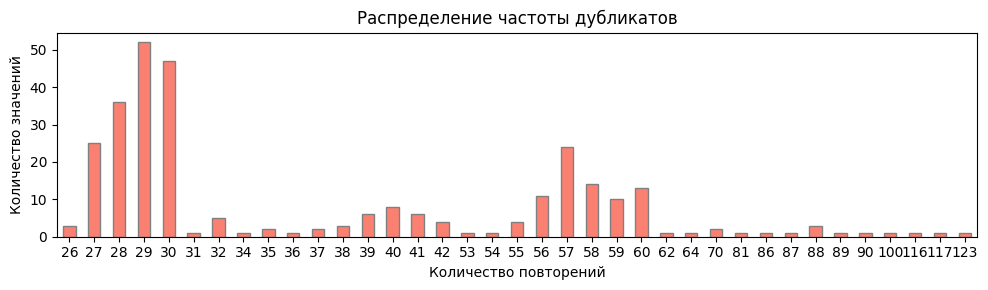

In [55]:
frequency_distribution(df['WikiData'])

> Индекс довольно много продублирован. Считаем что чистых данных (объектов) около 300

### Поле City

In [56]:
df.City.unique().shape[0]

4

In [57]:
df.City.unique()

array(['Екатеринбург', 'Нижний Новгород', 'Владимир', 'Ярославль'],
      dtype=object)

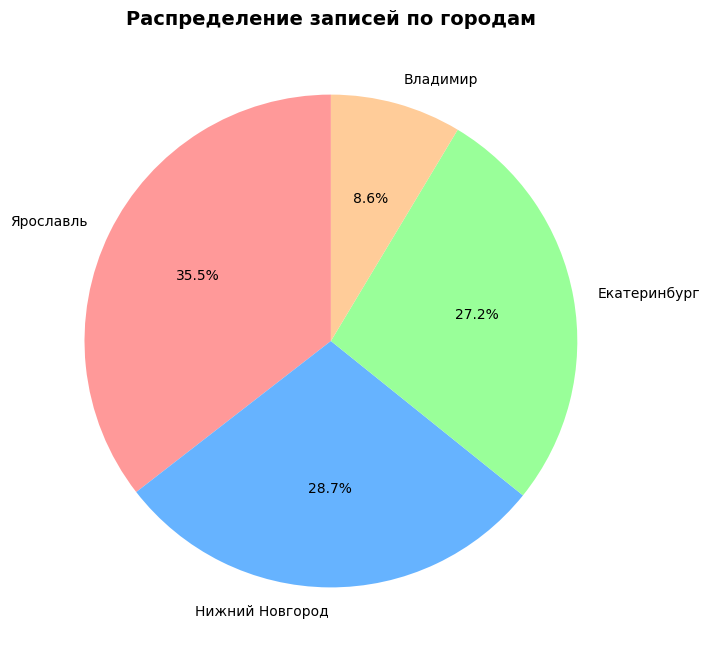

In [58]:
plt.figure(figsize=(8, 8))

city_counts = df['City'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']

plt.pie(city_counts.values, labels=city_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Распределение записей по городам', fontsize=14, fontweight='bold')

plt.show()

> Всего 4 города с перекосом распределения

### Поле description

In [59]:
df.description.unique().shape[0]

245

> Всего по всему датасету 245 уникальных описаний
>
> Это и есть конкретные достопримечательности во всех городах

In [60]:
df.description.unique()

array(['спорткомплекс в Екатеринбурге', 'здание в Екатеринбурге',
       'здание и достопримечательность в Екатеринбурге',
       'Дом Е.Д. Скрябиной', 'Музей',
       'Мемориальный дом-музей П. П. Бажова', 'кинотеатр в Екатеринбурге',
       'парк в Екатеринбурге', 'Храм Вознесения Господня (Екатеринбург)',
       'военно-учебное заведение в Екатеринбурге',
       'Троицкий собор (Екатеринбург)',
       'Литературно-мемориальный дом-музей Д. Н. Мамина-Сибиряка',
       'музей в Екатеринбурге', 'Памятник в Екатеринбурге',
       'Успенский собор (Екатеринбург)',
       'мост через Исеть в Екатеринбурге',
       'православный собор в Екатеринбурге', 'гостиница в Екатеринбурге',
       'высшее учебное заведение в Екатеринбурге',
       'стадион в Екатеринбурге', 'Преображенская церковь',
       'Второй Дом Советов (Екатеринбург)', 'сооружение в Екатеринбурге',
       'оперный театр в Екатеринбурге', 'памятник в Екатеринбурге',
       'геологический и археологический памятник природы в Ек

Построим распределение типов достопримечательностей по всему датасету

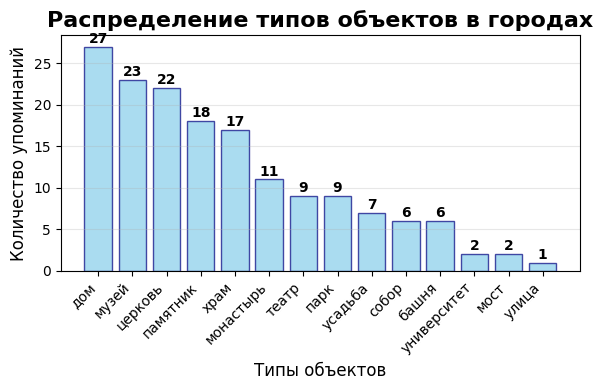

In [61]:
import re
import matplotlib.pyplot as plt

data = df['description'].unique()


# Функция для поиска вхождений
def count_types_in_data(data, types_list):
    counts = {type_name: 0 for type_name in types_list}

    for item in data:
        item_lower = item.lower()
        for type_name in types_list:
            # Ищем точные вхождения слов
            if re.search(r'\b' + re.escape(type_name) + r'\b', item_lower):
                counts[type_name] += 1

    return counts


# Подсчитываем вхождения
type_counts = count_types_in_data(data, type_freq)

# Сортируем по убыванию частоты
sorted_types = sorted(type_counts.items(), key=lambda x: x[1], reverse=True)
types, counts = zip(*sorted_types)

# Строим график
plt.figure(figsize=(6, 4))
bars = plt.bar(types, counts, color='skyblue', edgecolor='navy', alpha=0.7)

# Добавляем значения на столбцы
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             str(count), ha='center', va='bottom', fontweight='bold')

plt.title('Распределение типов объектов в городах', fontsize=16,
          fontweight='bold')
plt.xlabel('Типы объектов', fontsize=12)
plt.ylabel('Количество упоминаний', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

#### Смысловой анализ описания привязанного к городу

Выведем все описания привязанные к городу

In [62]:
def build_dichotomy_scheme_detailed(df):
    scheme = {}

    for city in df['City'].unique():
        city_data = df[df['City'] == city]
        descriptions = city_data['description'].unique()
        scheme[city] = {}

        for desc in descriptions:
            elements = city_data[city_data['description'] == desc][
                'Name'].tolist()
            scheme[city][desc] = len(elements)

    return scheme


def print_detailed_scheme(scheme):
    for city in scheme:
        print(f"\n### **{city}**")
        print("```")
        descriptions = list(scheme[city].keys())
        for i, desc in enumerate(descriptions):
            num = scheme[city][desc]
            if i == len(descriptions) - 1:
                print(f"└── {desc} {num}")
            else:
                print(f"├── {desc} {num}")
        print("```")


# Использование
scheme = build_dichotomy_scheme_detailed(df)
print_detailed_scheme(scheme)


### **Екатеринбург**
```
├── спорткомплекс в Екатеринбурге 41
├── здание в Екатеринбурге 287
├── здание и достопримечательность в Екатеринбурге 55
├── Дом Е.Д. Скрябиной 28
├── Музей 27
├── Мемориальный дом-музей П. П. Бажова 29
├── кинотеатр в Екатеринбурге 40
├── парк в Екатеринбурге 31
├── Храм Вознесения Господня (Екатеринбург) 57
├── военно-учебное заведение в Екатеринбурге 32
├── Троицкий собор (Екатеринбург) 30
├── Литературно-мемориальный дом-музей Д. Н. Мамина-Сибиряка 29
├── музей в Екатеринбурге 285
├── Памятник в Екатеринбурге 116
├── Успенский собор (Екатеринбург) 29
├── мост через Исеть в Екатеринбурге 69
├── православный собор в Екатеринбурге 27
├── гостиница в Екатеринбурге 29
├── высшее учебное заведение в Екатеринбурге 58
├── стадион в Екатеринбурге 40
├── Преображенская церковь 57
├── Второй Дом Советов (Екатеринбург) 30
├── сооружение в Екатеринбурге 78
├── оперный театр в Екатеринбурге 40
├── памятник в Екатеринбурге 204
├── геологический и археологический памятни

Списки имеют в составе явные абстрактные названия, которые слабо описывают конкретные достопримечательности. Постоим списки не конкретных объектов для каждого города с помощью LLM.

**Промпт**: Дан список объектов в городе. Выдели в отдельный список python  все не конкретные объекты.

Пример не конкретных объектов в городе:
- здание в Екатеринбурге
- Музей
- Памятник в Екатеринбурге

Пример  хорошо идентифицированных объектов в городе :
- Дом Е.Д. Скрябиной
- Мемориальный дом-музей П. П. Бажова

Не включай в список значимые места в городе пример
- спорткомплекс
- гостиница
- мост
- университет

список объектов в городе: ...

**Екатеринбург**
```
├── спорткомплекс в Екатеринбурге
├── здание в Екатеринбурге
├── здание и достопримечательность в Екатеринбурге
├── Дом Е.Д. Скрябиной
├── Музей
├── Мемориальный дом-музей П. П. Бажова
├── кинотеатр в Екатеринбурге
├── парк в Екатеринбурге
├── Храм Вознесения Господня (Екатеринбург)
├── военно-учебное заведение в Екатеринбурге
├── Троицкий собор (Екатеринбург)
├── Литературно-мемориальный дом-музей Д. Н. Мамина-Сибиряка
├── музей в Екатеринбурге
├── Памятник в Екатеринбурге
├── Успенский собор (Екатеринбург)
├── мост через Исеть в Екатеринбурге
├── православный собор в Екатеринбурге
├── гостиница в Екатеринбурге
├── высшее учебное заведение в Екатеринбурге
├── стадион в Екатеринбурге
├── Преображенская церковь
├── Второй Дом Советов (Екатеринбург)
├── сооружение в Екатеринбурге
├── оперный театр в Екатеринбурге
├── памятник в Екатеринбурге
├── геологический и археологический памятник природы в Екатеринбурге
├── Дом контор
├── часовня в Екатеринбурге
├── комплекс зданий в стиле конструктивизма
├── церковь в Екатеринбурге
├── профессиональное учебное заведение Екатеринбурга
├── главная площадь Екатеринбурга
├── Музей кукол и детской книги «Страна чудес»
├── здание в Железнодорожном районе Екатеринбурга
├── Екатеринбургское художественное училище им. И. Д. Шадра
├── концертный зал в Екатеринбурге
├── учебное заведение в Екатеринбурге
├── Музей истории плодового садоводства Среднего Урала
├── Литературно-мемориальный дом-музей Ф. М. Решетникова
├── православный храм в Екатеринбурге
├── Ново-Тихвинский монастырь
├── Дом купца Чувильдина
├── Свердловский областной краеведческий музей
├── музыкальный театр в Екатеринбурге
├── Дом актёра (Екатеринбург)
├── улица в Екатеринбурге
├── Мемориальный комплекс в Екатеринбурге
├── металлургический завод (XVIII век)
├── предприятие в Екатеринбурге
├── Усадьба Железнова
├── Усадьба ротмистра Переяславцева
├── Комплекс штаба военного округа
├── университет в Екатеринбурге
├── бывшее название университета в Екатеринбурге
├── городская площадь в Екатеринбурге
├── Усадьба Тарасова
├── Здание пансиона и церкви Святой Магдалины при первой женской гимназии
├── Дом Бревновых
├── деревянный особняк начала XX века на Вознесенской горке в Екатеринбурге
├── историческое здание в Екатеринбурге
├── Крестовоздвиженская церковь (Екатеринбург)
├── Литературный музей в Екатеринбурге
├── Библиотека в Екатеринбурге
├── Дом Гайдара
└── Дом дворянки Е. О. Селивановой
```

In [42]:
non_specific_objects_ecat = {"здание в Екатеринбурге", "Музей",
                             "Памятник в Екатеринбурге",
                             "спорткомплекс в Екатеринбурге",
                             "здание и достопримечательность в Екатеринбурге",
                             "кинотеатр в Екатеринбурге",
                             "парк в Екатеринбурге",
                             "военно-учебное заведение в Екатеринбурге",
                             "музей в Екатеринбурге",
                             "мост через Исеть в Екатеринбурге",
                             "православный собор в Екатеринбурге",
                             "гостиница в Екатеринбурге",
                             "высшее учебное заведение в Екатеринбурге",
                             "стадион в Екатеринбурге",
                             "сооружение в Екатеринбурге",
                             "оперный театр в Екатеринбурге",
                             "памятник в Екатеринбурге",
                             "геологический и археологический памятник природы в Екатеринбурге",
                             "часовня в Екатеринбурге",
                             "комплекс зданий в стиле конструктивизма",
                             "церковь в Екатеринбурге",
                             "профессиональное учебное заведение Екатеринбурга",
                             "главная площадь Екатеринбурга",
                             "здание в Железнодорожном районе Екатеринбурга",
                             "концертный зал в Екатеринбурге",
                             "учебное заведение в Екатеринбурге",
                             "православный храм в Екатеринбурге",
                             "музыкальный театр в Екатеринбурге",
                             "улица в Екатеринбурге",
                             "Мемориальный комплекс в Екатеринбурге",
                             "металлургический завод (XVIII век)",
                             "предприятие в Екатеринбурге",
                             "университет в Екатеринбурге",
                             "бывшее название университета в Екатеринбурге",
                             "городская площадь в Екатеринбурге",
                             "деревянный особняк начала XX века на Вознесенской горке в Екатеринбурге",
                             "историческое здание в Екатеринбурге",
                             "Литературный музей в Екатеринбурге",
                             "Библиотека в Екатеринбурге"}

non_specific_objects_rare_ecat = {"спорткомплекс в Екатеринбурге",
                                  "парк в Екатеринбурге",
                                  "военно-учебное заведение в Екатеринбурге",
                                  "мост через Исеть в Екатеринбурге",
                                  "гостиница в Екатеринбурге",
                                  "стадион в Екатеринбурге",
                                  "оперный театр в Екатеринбурге",
                                  "главная площадь Екатеринбурга",
                                  "концертный зал в Екатеринбурге",
                                  "музыкальный театр в Екатеринбурге",
                                  "городская площадь в Екатеринбурге", }

non_specific_objects_ecat = non_specific_objects_ecat - non_specific_objects_rare_ecat

**Нижний Новгород**
```
├── Дом В. И. Смирнова
├── Памятник В. И. Ленину на площади Ленина (Нижний Новгород)
├── круглая башня Нижегородского кремля
├── проездная башня Нижегородского кремля
├── Жилой дом горьковского архитектора А. А. Яковлева
├── Старейший театр Нижнего Новгорода
├── Крепость в центре Нижнего Новгорода
├── Нижегородская соборная мечеть
├── музей в Нижнем Новгороде (Россия)
├── Автозаводский парк
├── православный собор в Нижнем Новгороде
├── православный храм
├── Церковь Рождества Богородицы в селе Гнилицы
├── Спасо-Преображенская церковь (Карповка)
├── административное здание в Нижнем Новгороде, Россия
├── Парк Кулибина
├── Воскресенская церковь (Нижний Новгород)
├── Церковь Сергия Радонежского
├── Храм Святителей Московских (Нижний Новгород)
├── Торговый дом Скоба
├── историческое здание в Нижнем Новгороде, Россия
├── проездная башня Нижегородского кремля, один из символов Нижнего Новгорода
├── Лицей № 82 "Школа баррикад"
├── Мемориал «Горьковчане — фронту»
├── один из старейших музеев России, крупнейший музей изобразительного искусства в Нижегородской области.
├── Церковь в Нижнем Новгороде
├── Музей-квартира А. М. Горького (Нижний Новгород)
├── монастырь в Нижнем Новгороде
├── чебное заведение среднего профессионального образования в Нижнем Новгороде, готовящее специалистов водного транспорта.С 2005 года — филиал Волжской государственной академии водного транспорта, которая сейчас называется ВГУВТ.
├── парк культуры и отдыха в Нижнем Новгороде.
├── Монумент героям Волжской военной флотилии (Нижний Новгород)
├── здание в Нижегородском кремле, Россия
├── Памятник героям и жертвам революции 1905 года
├── Домик Петра I (Нижний Новгород)
├── Государственный банк (Нижний Новгород)
├── Усадьба С. М. Рукавишникова
├── Нижегородский государственный академический театр оперы и балета имени А. С. Пушкина
├── памятник в Нижнем Новгороде, Россия
├── Церковь Жен-Мироносиц (Нижний Новгород)
├── Нижегородский острог
├── Сормовский парк
├── Блиновский пассаж
├── Памятник градостроительства и архитектуры
├── Общежитие института инженеров водного транспорта с кинотеатром «Рекорд»
├── Нижегородская государственная консерватория имени М. И. Глинки
├── Церковь Рождества Иоанна Предтечи на Торгу
├── единственный в мире музей литературного критика и писателя Николая Александровича Добролюбова, расположенный в Нижнем Новгороде.
├── памятник архитектуры Нижнего Новгорода, корпус Художественного музея
├── Собор на Нижегородской ярмарке
├── башня Нижегородского кремля
├── многоцелевой стадион в Нижнем Новгороде, Россия
├── Крестовоздвиженский монастырь (Нижний Новгород)
├── Дом П. Е. Кубаревой
├── лестница на Волжском откосе в Нижнем Новгороде
├── Храм Всемилостивого Спаса (Нижний Новгород)
├── соборный храм в Нижегородском районе Нижнего Новгорода
├── Спасо-Преображенская церковь (Старые Печёры)
├── Нижегородская радиолаборатория
├── парк в Нижегородском кремле, Россия
├── памятник в России
├── православный храм в Нижнем Новгороде
├── церковь в Нижнем Новгороде
├── Здание Удельной конторы
├── Церковь Александра Невского в Сормово
├── Усадьба Вяхиревых
├── Дом Ермолаевых — П. Парфёнова
├── Доходный дом Б. Н. Юсупова
├── Торговый флигель О. Н. Каменевой
├── Дом Е. Трушенинниковой
├── Дом Виноградовых
├── Дом М. В. Медведева
├── Здание Волжско-Камского банка
├── Дом И. Н. Соболева
├── Дом А. И. Фролова
├── православный храм в г. Кстово, Нижегородская область
├── Усадьба Е. И. Богоявленской
├── Усадьба Киршбаумов
├── памятник
└── Дом культуры ГУВД (Нижний Новгород)
```

In [43]:
non_specific_objects_nn = {"круглая башня Нижегородского кремля",
                           "проездная башня Нижегородского кремля",
                           "Старейший театр Нижнего Новгорода",
                           "Крепость в центре Нижнего Новгорода",
                           "музей в Нижнем Новгороде (Россия)",
                           "православный собор в Нижнем Новгороде",
                           "православный храм",
                           "административное здание в Нижнем Новгороде, Россия",
                           "один из старейших музеев России, крупнейший музей изобразительного искусства в Нижегородской области",
                           "Церковь в Нижнем Новгороде",
                           "монастырь в Нижнем Новгороде",
                           "чебное заведение среднего профессионального образования в Нижнем Новгороде, готовящее специалистов водного транспорта.С 2005 года — филиал Волжской государственной академии водного транспорта, которая сейчас называется ВГУВТ",
                           "парк культуры и отдыха в Нижнем Новгороде",
                           "здание в Нижегородском кремле, Россия",
                           "памятник в Нижнем Новгороде, Россия",
                           "Памятник градостроительства и архитектуры",
                           "единственный в мире музей литературного критика и писателя Николая Александровича Добролюбова, расположенный в Нижнем Новгороде",
                           "башня Нижегородского кремля",
                           "многоцелевой стадион в Нижнем Новгороде, Россия",
                           "соборный храм в Нижегородском районе Нижнего Новгорода",
                           "парк в Нижегородском кремле, Россия",
                           "памятник в России",
                           "православный храм в Нижнем Новгороде",
                           "церковь в Нижнем Новгороде", "памятник"}
non_specific_objects_rare_nn = {"круглая башня Нижегородского кремля",
                                "проездная башня Нижегородского кремля",
                                "Старейший театр Нижнего Новгорода",
                                "Крепость в центре Нижнего Новгорода",
                                "парк культуры и отдыха в Нижнем Новгороде",
                                "единственный в мире музей литературного критика и писателя Николая Александровича Добролюбова, расположенный в Нижнем Новгороде",
                                "башня Нижегородского кремля",
                                "многоцелевой стадион в Нижнем Новгороде, Россия",
                                "парк в Нижегородском кремле, Россия", }
non_specific_objects_nn = non_specific_objects_nn - non_specific_objects_rare_nn


**Владимир**
```
├── Никитская церковь
├── Владимирский авиамеханический колледж
├── православный храм во Владимире, памятник белокаменного зодчества домонгольской Руси
├── Троицкая церковь
├── Мемориальный музей в городе Владимире, посвящённый жизни и деятельности выдающегося учёного-физика А. Г. Столетова и генерала от инфантерии Н. Г. Столетова, сыгравшего видную роль в освобождении Болгарии от турецкого ига
├── Музей во Владимире, Россия
├── православный кладбищенский храм во Владимире
├── театр города Владимира
├── Здание присутственных мест
├── достопримечательность во Владимире
├── католический храм в городе Владимир
├── Православный храм во Владимире
├── Богородице-Рождественский монастырь (Владимир)
├── Успенский Княгинин монастырь
├── памятник XII века во Владимире
├── Тюрьма в городе Владимир
├── Владимирский государственный гуманитарный университет
├── Владимирское духовное училище
├── Белокаменные памятники Владимира и Суздаля
├── Владимирский планетарий
├── Храм Казанской иконы Божией Матери
├── Здание городской думы
├── Музей ложки
├── некрополь во Владимире
├── Владимирский кремль
├── Владимиро-Суздальский музей-заповедник
├── Владимирская духовная семинария
├── Армянская церковь в г. Владимир России
└── Лесной парк «Дружба»
```

In [44]:
non_specific_objects_vl = {
    "православный храм во Владимире, памятник белокаменного зодчества домонгольской Руси",
    "Музей во Владимире, Россия",
    "православный кладбищенский храм во Владимире", "театр города Владимира",
    "достопримечательность во Владимире", "католический храм в городе Владимир",
    "Православный храм во Владимире", "памятник XII века во Владимире",
    "Тюрьма в городе Владимир", "Белокаменные памятники Владимира и Суздаля",
    "некрополь во Владимире", "Армянская церковь в г. Владимир России"}
non_specific_objects_rare_vl = {
    "православный храм во Владимире, памятник белокаменного зодчества домонгольской Руси",
    "театр города Владимира", "католический храм в городе Владимир",
    "Тюрьма в городе Владимир", "Армянская церковь в г. Владимир России"}

non_specific_objects_vl = non_specific_objects_vl - non_specific_objects_rare_vl


**Ярославль**
```
├── Православный храм в Ярославле
├── Архитектурный ансамбль в Ярославле
├── Церковь великомученика Димитрия Солунского (Смоленская) (Ярославль)
├── образовательное учреждение в Ярославле
├── Беседка на Волжской набережной
├── ГАУЗ ЯО Клиническая больница скорой медицинской помощи имени Н. В. Соловьёва
├── Бутусовский посёлок
├── Вечный огонь (Ярославль)
├── Владимирская церковь на Божедомке
├── Крепостная башня в Ярославле
├── Городской сад в Ярославле
├── Воинское мемориальное кладбище (Ярославль)
├── Башня в Ярославле
├── Памятник Георгию Димитрову (Ярославль)
├── Памятный знак городам-побратимам (Ярославль)
├── Торговые ряды в Ярославле
├── Губернаторский дом (Ярославль)
├── Демидовский сад
├── Демидовский столп (Ярославль)
├── Дом Болконского
├── Дом муз
├── Исторический центр Ярославля
├── Казанский монастырь (Ярославль)
├── Монастырь в Ярославле
├── приход в Ярославле
├── Крестобогородская церковь
├── кладбище в Ярославле
├── белорусский поэт, публицист, литературовед, переводчик.
├── Памятник Михаилу Фрунзе (Ярославль)
├── Мемориальный дом-музей М. Богдановича
├── Михайловские курганы
├── мост в Ярославле
├── Музей в Ярославле
├── Митрополичьи палаты (Ярославль)
├── художественный музей в Ярославле
├── Музей истории города Ярославля
├── Частный музей
├── Памятник в Ярославле
├── храм в Ярославле
├── Николо-Сковородский монастырь
├── Церковь в Ярославле
├── Памятник жертвам белогвардейского мятежа
├── Памятник Леониду Трефолеву (Ярославль)
├── Парк в Ярославле
├── Петровский монастырь (Ярославль)
├── Петропавловский парк
├── Приход Воздвижения Святого Креста (Ярославль)
├── Российский академический театр драмы им. Ф. Волкова
├── монастырь в Ярославле
├── Храм в Ярославле
├── Ярославский государственный театр кукол
├── Тимерёвский археологический комплекс
├── Женский православный монастырь Ярославской епархии
├── кафедральный собор в Ярославле
├── Памятник Фёдору Толбухину (Ярославль)
├── Церковь Михаила Архангела
├── Храм в честь Ярославской иконы Божией Матери
├── Благовещенско-Вознесенский приход
├── Вознесенско-Сретенский приход
├── Церковь Рождества Христова
├── Ярославский государственный цирк
├── часовня в Ярославле
├── Часовня Казанской Богоматери (Ярославль)
├── Школа № 33 имени Карла Маркса
├── Ярославская соборная мечеть
├── Театр в Ярославле
├── Ярославский дворец молодёжи
├── Ярославский зоопарк
├── Ярославский камерный театр
├── Ярославский музей-заповедник
├── высшее военное училище в России
└── Ярославское художественное училище
```


In [45]:
non_specific_objects_yar = {"Православный храм в Ярославле",
                            "Архитектурный ансамбль в Ярославле",
                            "образовательное учреждение в Ярославле",
                            "Крепостная башня в Ярославле", "Башня в Ярославле",
                            "Торговые ряды в Ярославле",
                            "Монастырь в Ярославле", "приход в Ярославле",
                            "кладбище в Ярославле", "мост в Ярославле",
                            "Музей в Ярославле",
                            "художественный музей в Ярославле", "Частный музей",
                            "Памятник в Ярославле", "храм в Ярославле",
                            "Церковь в Ярославле", "Парк в Ярославле",
                            "монастырь в Ярославле", "Храм в Ярославле",
                            "кафедральный собор в Ярославле",
                            "Театр в Ярославле", "часовня в Ярославле",
                            "высшее военное училище в России"}
non_specific_objects_rare_yar = {"Крепостная башня в Ярославле",
                                 "Торговые ряды в Ярославле",
                                 "Парк в Ярославле",
                                 "кафедральный собор в Ярославле",
                                 "высшее военное училище в России"}
non_specific_objects_yar = non_specific_objects_yar - non_specific_objects_rare_yar

Посмотрим какие записи с не специфичными названиями

In [46]:
df[(df['description'].isin(non_specific_objects_ecat)) & (
        df['City'] == 'Екатеринбург')].sample(10)

,Num,Name,WikiData,City,Lon,Lat,description,image,en_txt
2173,2173,Добровольцам-танкистам,Q4343452,Екатеринбург,60.606125,56.857285,памятник в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large tank sitting on a pedestal in...
998,998,Уральский геологический музей,Q4476747,Екатеринбург,60.595470,56.826492,музей в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed display of various types of rocks and o...
846,846,Уральская государственная консерватория,Q4476712,Екатеринбург,60.599995,56.837444,высшее учебное заведение в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a picture of a building with a flag o...
2170,2170,Добровольцам-танкистам,Q4343452,Екатеринбург,60.606125,56.857285,памятник в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,people are marching in a parade with flags and...
2384,2384,улица Февральской Революции,Q4474328,Екатеринбург,60.593147,56.841328,улица в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,an old photo of a run down house with a lot of...
3194,3420,Центральная городская библиотека им. А. И. Гер...,Q4504106,Екатеринбург,60.612167,56.821865,Библиотека в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a tall building with a clock on the t...
1878,1878,Уральский политехнический колледж,Q4476776,Екатеринбург,60.634628,56.842449,учебное заведение в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a building with columns and col...
1306,1306,Комсомолу Урала,Q107583229,Екатеринбург,60.610554,56.844635,памятник в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a church with a statue in front...
2774,3000,Уральский государственный технический университет,Q1938341,Екатеринбург,60.654282,56.844051,бывшее название университета в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a large building with a courtya...
1710,1710,"Музей истории, науки и техники Свердловской же...",Q4441173,Екатеринбург,60.600773,56.858772,здание в Железнодорожном районе Екатеринбурга,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a red and white roof and ...


In [47]:
df[(df['description'].isin(non_specific_objects_nn)) & (
        df['City'] == 'Нижний Новгород')].sample(10)

,Num,Name,WikiData,City,Lon,Lat,description,image,en_txt
4506,1280,Гарнизонная казарма,Q100701435,Нижний Новгород,44.004299,56.327614,"здание в Нижегородском кремле, Россия",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a large yellow building with a ...
3553,327,Домик Каширина,Q4165827,Нижний Новгород,43.990692,56.323921,музей в Нижнем Новгороде (Россия),/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,"there is a room with a bed, a table and a chair"
4327,1101,Благовещенский монастырь,Q4087775,Нижний Новгород,43.976791,56.323032,монастырь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a large white building with a g...
3785,559,Дворец вице-губернатора,Q99622643,Нижний Новгород,44.003147,56.327217,"административное здание в Нижнем Новгороде, Ро...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large white building with a canopy ...
4372,1146,Благовещенский собор,Q4087775,Нижний Новгород,43.976471,56.322552,монастырь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed white building with green roof and two ...
5791,2645,Храм Живоначальной Троицы,Q16715808,Нижний Новгород,44.046577,56.308556,соборный храм в Нижегородском районе Нижнего Н...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are people walking on the sidewalk near ...
5930,2784,М. Горькому,Q4343244,Нижний Новгород,43.990711,56.313480,памятник в России,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,a picture of a clock and a statue in a snowy f...
4358,1132,Благовещенский собор,Q4087775,Нижний Новгород,43.976471,56.322552,монастырь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a large white building with a g...
4331,1105,Благовещенский собор,Q4087775,Нижний Новгород,43.976471,56.322552,монастырь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed white building with green domes and a g...
5582,2436,Дом Советов,Q28032873,Нижний Новгород,44.005836,56.328762,"административное здание в Нижнем Новгороде, Ро...",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a lot of windows and a lo...


In [48]:
df[(df['description'].isin(non_specific_objects_nn)) & (
        df['City'] == 'Нижний Новгород')].sample(10)

,Num,Name,WikiData,City,Lon,Lat,description,image,en_txt
5772,2626,Храм Живоначальной Троицы,Q16715808,Нижний Новгород,44.046577,56.308556,соборный храм в Нижегородском районе Нижнего Н...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a gate leading to a building wi...
4301,1075,Благовещенский монастырь,Q4087775,Нижний Новгород,43.976791,56.323032,монастырь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a church with a golden dome and...
4374,1148,Благовещенский собор,Q4087775,Нижний Новгород,43.976471,56.322552,монастырь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a large white building with two...
6136,2990,Церковь во имя Святого Пророка Божия Илии,Q59901,Нижний Новгород,43.993713,56.328205,церковь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,a drawing of a city with a church and a river
6114,2968,Церковь во имя Святого Пророка Божия Илии,Q59901,Нижний Новгород,43.993713,56.328205,церковь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a city with a church and a tower
4349,1123,Благовещенский собор,Q4087775,Нижний Новгород,43.976471,56.322552,монастырь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a large white building with gre...
4513,1287,Гарнизонная казарма,Q100701435,Нижний Новгород,44.004299,56.327614,"здание в Нижегородском кремле, Россия",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a red chair sitting on the side of a ...
6228,3082,Печёрский Вознесенский монастырь,Q3860437,Нижний Новгород,44.049721,56.322777,монастырь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed ceiling with a painting of the virgin a...
4194,968,Рождественская церковь,Q1574846,Нижний Новгород,43.984966,56.327251,Церковь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a church with a clock tower and...
6139,2993,Церковь во имя Святого Пророка Божия Илии,Q59901,Нижний Новгород,43.993713,56.328205,церковь в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,a close up of a building with a clock on it


In [49]:
df[(df['description'].isin(non_specific_objects_vl)) & (
        df['City'] == 'Владимир')].sample(10)

,Num,Name,WikiData,City,Lon,Lat,description,image,en_txt
7231,480,Дмитриевский собор,Q550346,Владимир,40.410942,56.129208,Православный храм во Владимире,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a golden dome on top of it
7371,620,Золотые ворота,Q775020,Владимир,40.397278,56.126831,памятник XII века во Владимире,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a white building with a golden dome o...
7213,462,Дмитриевский собор,Q550346,Владимир,40.410942,56.129208,Православный храм во Владимире,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a church with a clock tower and...
7642,891,Князь-Владимирское кладбище,Q19691959,Владимир,40.434685,56.143505,некрополь во Владимире,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed man in a park setting next to a grave
6997,246,Исторический музей,Q21639947,Владимир,40.410965,56.130333,"Музей во Владимире, Россия",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a red brick building with a clock on ...
7366,615,Золотые ворота,Q775020,Владимир,40.397278,56.126831,памятник XII века во Владимире,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a large white building with a g...
7034,283,Князь-Владимирская церковь,Q65062793,Владимир,40.436531,56.142860,православный кладбищенский храм во Владимире,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed roof of a church with a cross on top
7018,267,Князь-Владимирская церковь,Q65062793,Владимир,40.436531,56.142860,православный кладбищенский храм во Владимире,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,people are walking around a white church with ...
7374,623,Золотые ворота,Q775020,Владимир,40.397278,56.126831,памятник XII века во Владимире,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,a view of a large white building with a golden...
7164,413,Бывшая водонапорная башня,Q4114100,Владимир,40.398781,56.125111,достопримечательность во Владимире,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a man standing in front of a red bric...


In [50]:
df[(df['description'].isin(non_specific_objects_yar)) & (
        df['City'] == 'Ярославль')].sample(10)

,Num,Name,WikiData,City,Lon,Lat,description,image,en_txt
14170,3908,Часовня Александра Невского,Q4507592,Ярославль,39.891064,57.625462,часовня в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAICAgICAQICAg...,arafed image of a park with a statue and benches
12744,2482,Спасо-Афанасиевский Ярославский монастырь,Q4221355,Ярославль,39.895222,57.625370,Монастырь в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,trees in front of a building with a clock tower
14062,3800,Церковь Софии Премудрости Божией в Савино,Q16715786,Ярославль,39.919182,57.623425,Церковь в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a building with a clock tower and a f...
10552,290,Богоявленская башня,Q4504600,Ярославль,39.887489,57.620663,Православный храм в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,aerial view of a large white building with a g...
12157,1895,Николая Чудотворца,Q4504845,Ярославль,39.865314,57.610310,храм в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,an old picture of a large building with two to...
13407,3145,Храм Петра и Павла,Q12140265,Ярославль,39.843700,57.602531,Православный храм в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAICAgICAQICAg...,arafed image of a building with a fountain and...
12285,2023,Памятник 1000-летию Ярославля,Q25389078,Ярославль,39.904823,57.617668,Памятник в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,statue of a man holding a child in his arms
12851,2589,Сретенский храм,Q4438830,Ярославль,39.888905,57.625244,Храм в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a church with a blue and gold wall
13286,3024,Храм Великомученика Никиты,Q4319898,Ярославль,39.868584,57.623791,приход в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed priest standing in front of a casket wi...
11543,1281,Колокольня Никитского прихода,Q4319898,Ярославль,39.868759,57.623619,приход в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,aerial view of a church tower in a rural area


> не специфичное описание нельзя в полной силе использовать для отбрасывания записей, так как Name остается информативным, но можно использовать для оценки качества

### Поле Lat Lon

In [63]:
df.Lat.unique().shape

(322,)

In [64]:
df.Lon.unique().shape

(320,)

> Построим отображение географических точек

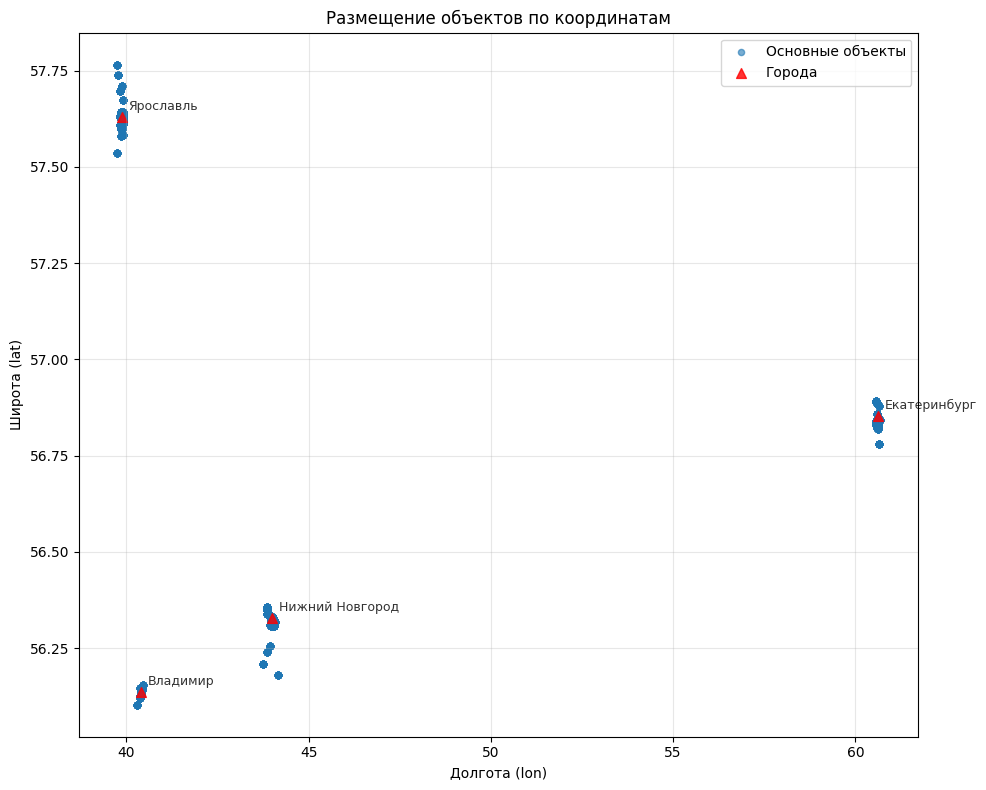

In [69]:
import matplotlib.pyplot as plt
import pandas as pd

# Создаем DataFrame из дополнительных данных
additional_data = pd.DataFrame(
    {'city': ['Екатеринбург', 'Нижний Новгород', 'Владимир', 'Ярославль'],
     'Lat': [56.8519, 56.3287, 56.1366, 57.6299],
     'Lon': [60.6122, 44.0020, 40.3966, 39.8737]})

plt.figure(figsize=(10, 8))

# Отрисовка основных объектов
plt.scatter(df['Lon'], df['Lat'], alpha=0.6, s=20, label='Основные объекты')

# Отрисовка дополнительных объектов (городов)
plt.scatter(additional_data['Lon'], additional_data['Lat'], alpha=0.8, s=50,
            color='red', marker='^', label='Города')

# Добавляем подписи для городов
for i, row in additional_data.iterrows():
    plt.annotate(row['city'], (row['Lon'], row['Lat']), xytext=(5, 5),
                 textcoords='offset points', fontsize=9, alpha=0.8)

plt.xlabel('Долгота (lon)')
plt.ylabel('Широта (lat)')
plt.title('Размещение объектов по координатам')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

> Выделим окрестности городов и построим отдельные схемы

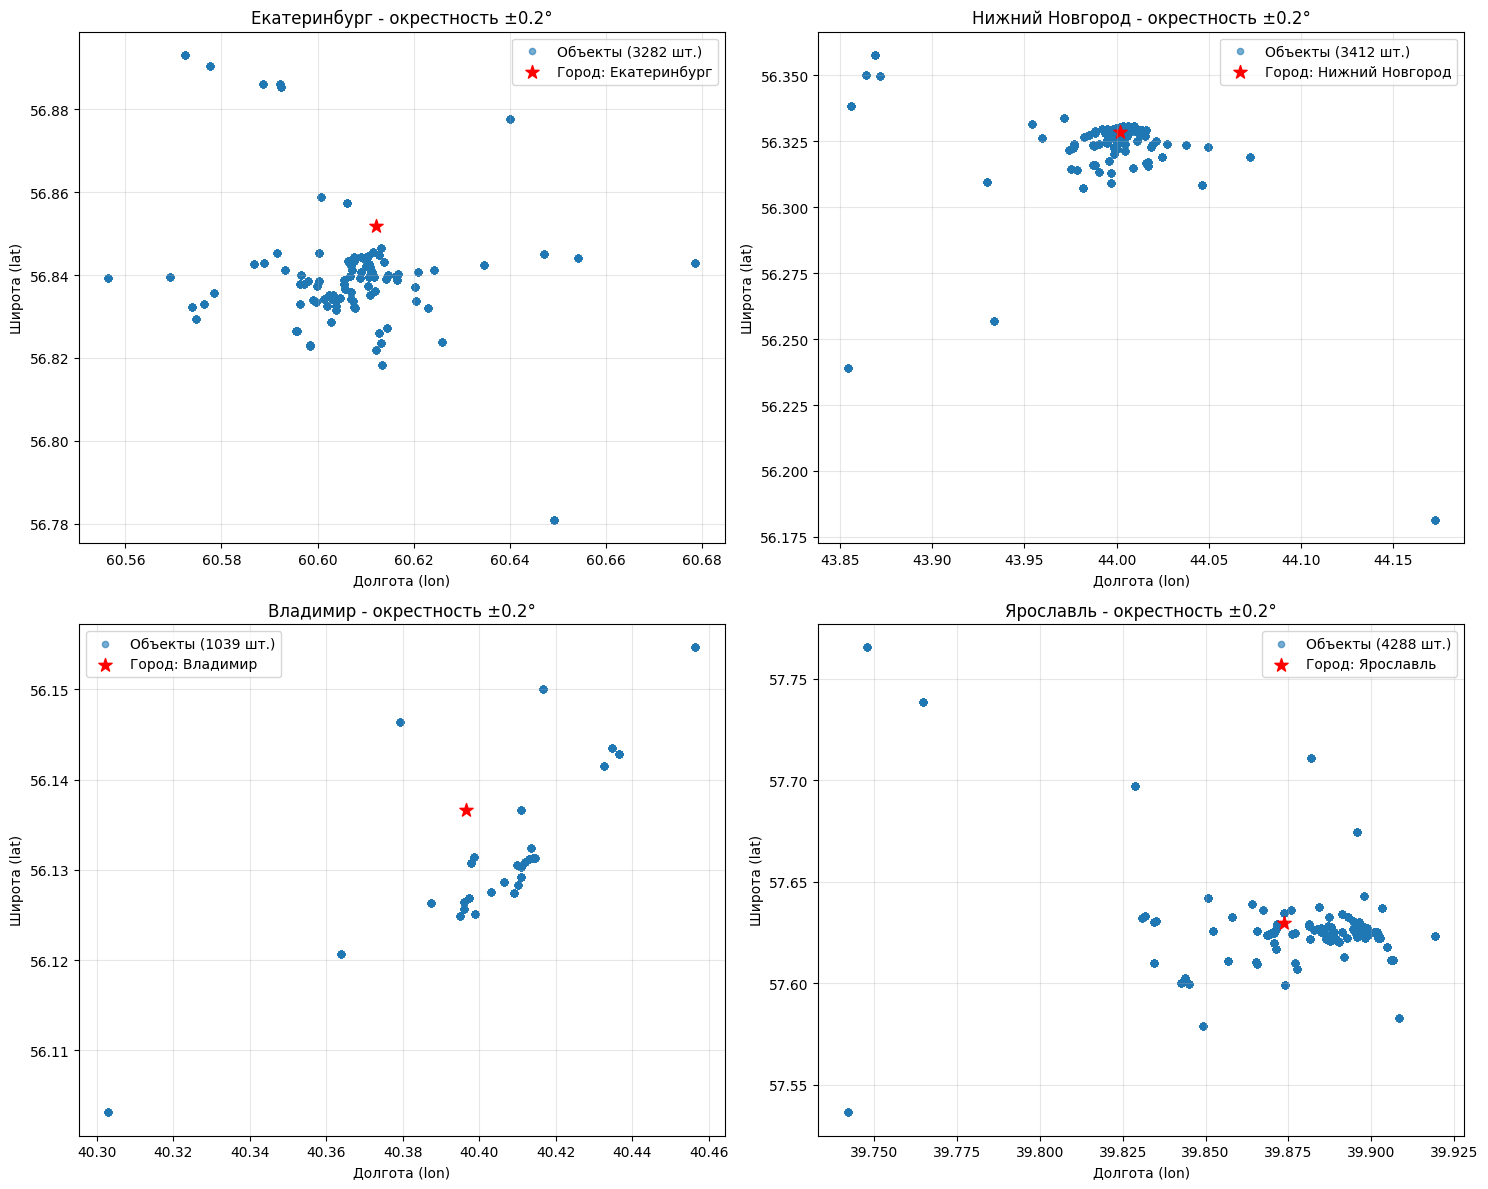

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, city in additional_data.iterrows():
    # Определяем границы окрестности ±0.2 градуса
    lat_min = city['Lat'] - 0.2
    lat_max = city['Lat'] + 0.2
    lon_min = city['Lon'] - 0.2
    lon_max = city['Lon'] + 0.2

    # Фильтруем объекты из df в окрестности города
    mask = (df['Lat'] >= lat_min) & (df['Lat'] <= lat_max) & (
            df['Lon'] >= lon_min) & (df['Lon'] <= lon_max)

    filtered_df = df[mask]

    # Отрисовываем на соответствующем subplot
    axes[i].scatter(filtered_df['Lon'], filtered_df['Lat'], alpha=0.6, s=20,
                    label=f'Объекты ({len(filtered_df)} шт.)')

    axes[i].scatter(city['Lon'], city['Lat'], alpha=1.0, s=100, color='red',
                    marker='*', label=f"Город: {city['city']}")

    axes[i].set_xlabel('Долгота (lon)')
    axes[i].set_ylabel('Широта (lat)')
    axes[i].set_title(f"{city['city']} - окрестность ±0.2°")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.show()

Построим частые объекты в отдельных городах, но редкие в конкретном городе

In [75]:
type_rare

['сад', 'сквер', 'гостиница', 'стадион', 'зоопарк', 'цирк', 'планетарий']

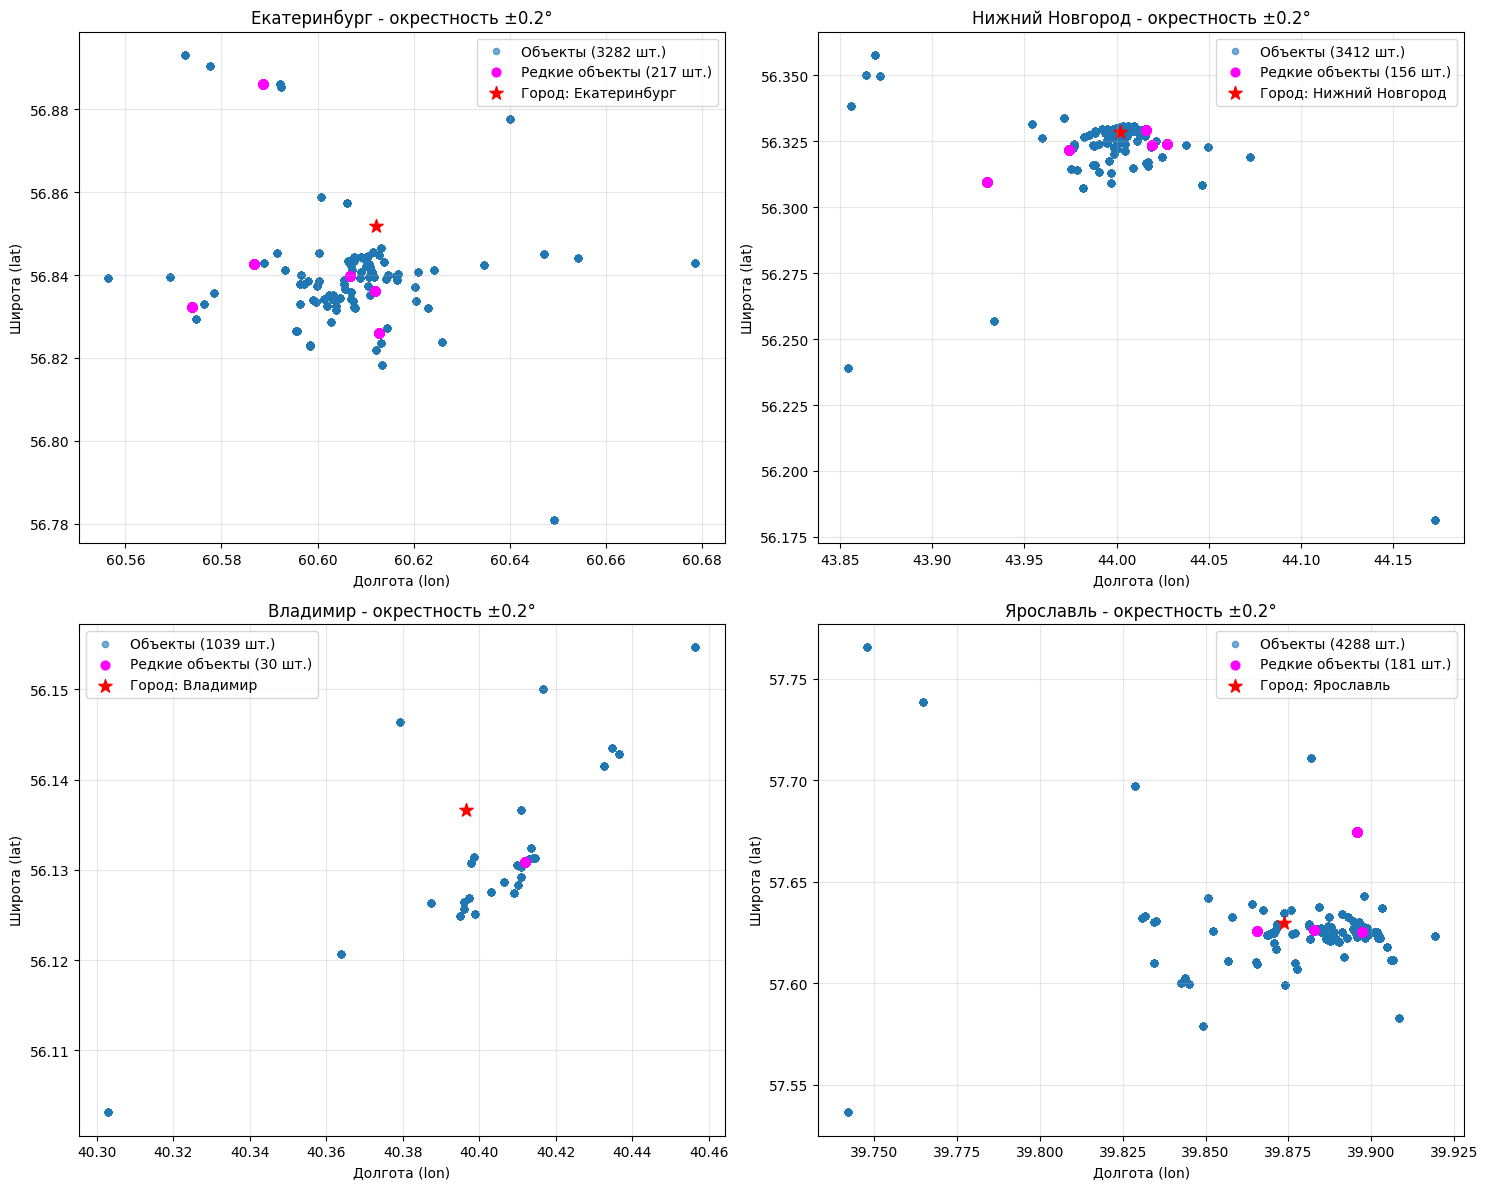

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, city in additional_data.iterrows():
    # Определяем границы окрестности ±0.2 градуса
    lat_min = city['Lat'] - 0.2
    lat_max = city['Lat'] + 0.2
    lon_min = city['Lon'] - 0.2
    lon_max = city['Lon'] + 0.2

    # Фильтруем объекты из df в окрестности города
    mask = (df['Lat'] >= lat_min) & (df['Lat'] <= lat_max) & (
            df['Lon'] >= lon_min) & (df['Lon'] <= lon_max)

    filtered_df = df[mask]

    # Отрисовываем все объекты на соответствующем subplot
    axes[i].scatter(filtered_df['Lon'], filtered_df['Lat'], alpha=0.6, s=20,
                    label=f'Объекты ({len(filtered_df)} шт.)')

    # Фильтруем и отмечаем объекты из type_rare зеленым цветом
    rare_mask = filtered_df['description'].str.contains('|'.join(type_rare),
                                                        case=False, na=False)
    rare_objects = filtered_df[rare_mask]

    if len(rare_objects) > 0:
        axes[i].scatter(rare_objects['Lon'], rare_objects['Lat'], alpha=1.0,
                        s=40, color='magenta', marker='o',
                        label=f'Редкие объекты ({len(rare_objects)} шт.)')

    axes[i].scatter(city['Lon'], city['Lat'], alpha=1.0, s=100, color='red',
                    marker='*', label=f"Город: {city['city']}")

    axes[i].set_xlabel('Долгота (lon)')
    axes[i].set_ylabel('Широта (lat)')
    axes[i].set_title(f"{city['city']} - окрестность ±0.2°")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.show()

### Поиск мусора в description

In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
# import pymorphy2

# Скачиваем русские стоп-слова (если еще не скачаны)
import nltk

nltk.download('stopwords')

# Получаем русские стоп-слова
russian_stop_words = stopwords.words('russian')

# Добавляем дополнительные стоп-слова, характерные для описаний достопримечательностей
additional_stop_words = ['россия', 'город', 'находиться', 'располагаться',
                         'являться', 'также', 'например', 'который', 'мочь',
                         'один', 'год', 'время']
# russian_stop_words.extend(additional_stop_words)
# Инициализация векторйзера с базовой предобработкой
# min_df отсекает слишком редкие слова, max_df - слишком частые (но мы их тоже посмотрим)

vectorizer = TfidfVectorizer(stop_words=russian_stop_words, # Русские стоп-слова
                             max_features=1000,  # Рассмотрим топ-1000 слов
                             min_df=2,
                             # Слово должно встретиться минимум в 2 документах
                             max_df=0.8,
                             # Исключаем слова, встречающиеся в >80% документов (как стоп-слова)
                             ngram_range=(1, 2),
                             # Учитываем не только отдельные слова, но и пары (биграммы)
                             analyzer='word',  # Анализируем по словам
                             lowercase=True,  # Приводим к нижнему регистру
                             )

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\k142\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [78]:
import numpy as np

# Применяем TF-IDF
tfidf_matrix = vectorizer.fit_transform(df['description'])

# Получаем названия признаков (слова/биграммы)
feature_names = vectorizer.get_feature_names_out()

# Вычисляем средний TF-IDF для каждого слова по всем документам
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

# Создаем DataFrame для анализа
tfidf_df = pd.DataFrame(
    {'feature': feature_names, 'mean_tfidf': mean_tfidf}).sort_values(
    'mean_tfidf', ascending=False)

Посмотрим на **топ-20** самых "важных" слов (высокий средний TF-IDF)

In [79]:
print("Топ-20 слов с наивысшим TF-IDF:")
print(tfidf_df.head(20))

Топ-20 слов с наивысшим TF-IDF:
                    feature  mean_tfidf
982               ярославле    0.061273
295           екатеринбурге    0.058870
916                    храм    0.044177
928          храм ярославле    0.036085
693            православный    0.035165
631                памятник    0.034393
697       православный храм    0.033272
535                   музей    0.029968
942                 церковь    0.024253
326                  здание    0.023773
249                     дом    0.021800
51                    башня    0.020434
638  памятник екатеринбурге    0.019363
598               новгороде    0.018251
586        нижнем новгороде    0.018251
585                  нижнем    0.018251
518               монастырь    0.018190
540     музей екатеринбурге    0.018144
330    здание екатеринбурге    0.017824
429                  кремля    0.016293


Посмотрим на **топ-20** самых "неважных" (низкий TF-IDF)

In [80]:
print("\nТоп-20 слов с наинизшим TF-IDF:")
print(tfidf_df.tail(20))


Топ-20 слов с наинизшим TF-IDF:
                      feature  mean_tfidf
100                    видную    0.000375
101               видную роль    0.000375
870             турецкого ига    0.000375
620              освобождении    0.000375
170       генерала инфантерии    0.000375
169                  генерала    0.000375
621     освобождении болгарии    0.000375
161       выдающегося учёного    0.000375
539              музей городе    0.000375
241              деятельности    0.000375
160               выдающегося    0.000375
242  деятельности выдающегося    0.000375
498        мемориальный музей    0.000375
688               посвящённый    0.000375
689         посвящённый жизни    0.000375
313                     жизни    0.000375
314        жизни деятельности    0.000375
194          городе владимире    0.000375
109     владимире посвящённый    0.000375
836         сыгравшего видную    0.000375


> Топ-20 часто встречающихся биграмм хорошо коллерируются с раннее найденными типами достопримечательностей

### Поиск мусора en_txt

Подразумеваем, что:
- предыдущий анализ показал, что много записей относятся к добавлению фотографий к объектам
- по описанию фото можно определить качество фото и записи для описания объекта


In [81]:
from sklearn.feature_extraction.text import TfidfVectorizer
# import pymorphy2

# Скачиваем русские стоп-слова (если еще не скачаны)
import nltk

nltk.download('stopwords')

vectorizer = TfidfVectorizer(stop_words='english',  # Русские стоп-слова
                             max_features=1000,  # Рассмотрим топ-1000 слов
                             min_df=2,
                             # Слово должно встретиться минимум в 2 документах
                             max_df=0.8,
                             # Исключаем слова, встречающиеся в >80% документов (как стоп-слова)
                             ngram_range=(1, 2),
                             # Учитываем не только отдельные слова, но и пары (биграммы)
                             analyzer='word',  # Анализируем по словам
                             lowercase=True,  # Приводим к нижнему регистру
                             )

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\k142\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [82]:
import numpy as np

# Применяем TF-IDF
tfidf_matrix = vectorizer.fit_transform(df['en_txt'])

# Получаем названия признаков (слова/биграммы)
feature_names = vectorizer.get_feature_names_out()

# Вычисляем средний TF-IDF для каждого слова по всем документам
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

# Создаем DataFrame для анализа
tfidf_df = pd.DataFrame(
    {'feature': feature_names, 'mean_tfidf': mean_tfidf}).sort_values(
    'mean_tfidf', ascending=False)

Посмотрим на **топ-20** самых "важных" слов (высокий средний TF-IDF)

In [84]:
print("Топ-20 слов с наивысшим TF-IDF:")
print(tfidf_df.head(20))

Топ-20 слов с наивысшим TF-IDF:
            feature  mean_tfidf
110        building    0.070168
7            arafed    0.061384
453           large    0.046563
242           clock    0.044971
916            view    0.042362
34      arafed view    0.038284
958           white    0.037677
869           tower    0.036387
200          church    0.035389
384           green    0.033735
121  building clock    0.031621
246     clock tower    0.029392
959  white building    0.027376
459  large building    0.026662
690            roof    0.025082
809         steeple    0.022494
925      view large    0.022288
501             man    0.021005
799          statue    0.020443
393      green roof    0.020252


Посмотрим на **топ-20** самых "неважных" (низкий TF-IDF)

In [85]:
print("\nТоп-20 слов с наинизшим TF-IDF:")
print(tfidf_df.tail(20))


Топ-20 слов с наинизшим TF-IDF:
              feature  mean_tfidf
950    wall paintings    0.000391
537       middle town    0.000391
671       riding bike    0.000389
450         lamp post    0.000388
784        stand line    0.000384
736    sitting chairs    0.000382
910     uniform stand    0.000381
278          crystals    0.000375
427        house blue    0.000374
295   display various    0.000372
661         red fence    0.000371
213        church lit    0.000370
654  priests standing    0.000370
106            broken    0.000362
931        view stage    0.000362
581        park river    0.000361
772     stadium green    0.000354
973       white table    0.000350
478    leading grassy    0.000341
664          red line    0.000323


Отбор незначащих слов

In [86]:
import pandas as pd
import re

junc_words = ["wall paintings", "middle town", "riding bike", "lamp post",
              "stand line", "sitting chairs", "uniform stand", "crystals",
              "house blue", "display various", "red fence", "church lit",
              "priests standing", "broken", "view stage", "park river",
              "stadium green", "white table", "leading grassy", "red line"]
# Создаем регулярное выражение из списка слов
pattern = '|'.join([re.escape(word) for word in junc_words])
df['is_junc_words'] = False
df['is_junc_words'] = df['en_txt'].str.contains(pattern, case=False, na=False)


def find_matching_text(text):
    if pd.isna(text):
        return None
    for word in junc_words:
        if word.lower() in str(text).lower():
            return word
    return None


df['found_text'] = df['en_txt'].apply(find_matching_text)

In [87]:
df[df['is_junc_words']]

,Num,Name,WikiData,City,Lon,Lat,description,image,en_txt,is_junc_words,found_text
198,198,Дом-музей Бажова,Q4290214,Екатеринбург,60.613415,56.818394,Мемориальный дом-музей П. П. Бажова,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a table with a white table cloth and ...,True,white table
347,347,Суворовское училище,Q4174329,Екатеринбург,60.647209,56.845078,военно-учебное заведение в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed group of military men in uniform standi...,True,uniform stand
348,348,Суворовское училище,Q4174329,Екатеринбург,60.647209,56.845078,военно-учебное заведение в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are many people in uniform standing in a...,True,uniform stand
349,349,Суворовское училище,Q4174329,Екатеринбург,60.647209,56.845078,военно-учебное заведение в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed military men in uniform stand in a line...,True,uniform stand
352,352,Суворовское училище,Q4174329,Екатеринбург,60.647209,56.845078,военно-учебное заведение в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAICAgICAQICAg...,arafed image of a group of men in uniform stan...,True,uniform stand
...,...,...,...,...,...,...,...,...,...,...,...
14525,4263,Ярославский филиал Военно-космической академии...,Q4538913,Ярославль,39.877613,57.607079,высшее военное училище в России,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed female soldiers in uniform stand in a line,True,uniform stand
14531,4269,Ярославский филиал Военно-космической академии...,Q4538913,Ярославль,39.877613,57.607079,высшее военное училище в России,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,a group of men in uniform stand in front of a ...,True,uniform stand
14533,4271,Ярославский филиал Военно-космической академии...,Q4538913,Ярославль,39.877613,57.607079,высшее военное училище в России,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,soldiers in uniform stand in a line in front o...,True,uniform stand
14534,4272,Ярославский филиал Военно-космической академии...,Q4538913,Ярославль,39.877613,57.607079,высшее военное училище в России,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed group of men in uniform standing in a line,True,uniform stand


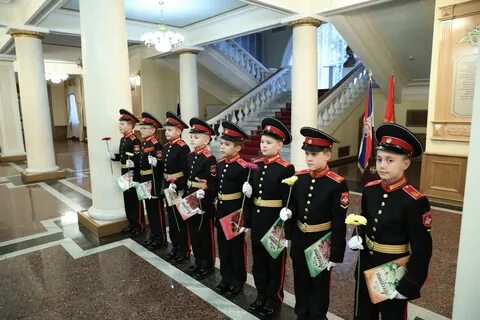

In [88]:
get_image(df.at[366, 'image'])

Построим предпросмотр фото из этого списка

In [90]:
import base64
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


def show_image_blocks_8x1(df, num_blocks=30, start_index=0, figsize=(16, 2),
                          image_size=(64, 64)):
    """
    Показывает блоки изображений 8x1 из DataFrame с уменьшенным размером

    Parameters:
    - df: DataFrame с колонкой 'image' содержащей base64 строки
    - num_blocks: количество блоков для показа (по умолчанию 1)
    - start_index: начальный индекс в DataFrame (по умолчанию 0)
    - figsize: размер фигуры (по умолчанию (16, 2))
    - image_size: размер для ресайза изображений (по умолчанию (64, 64))
    """

    for block_num in range(num_blocks):
        # Создаем фигуру для одной линии (1x8)
        fig, axes = plt.subplots(1, 8, figsize=figsize)

        # Если axes не является массивом, преобразуем в массив для единообразия
        if not hasattr(axes, '__iter__'):
            axes = [axes]

        # Вычисляем начальный индекс для текущего блока
        current_start = start_index + (block_num * 8)

        for i in range(8):
            idx = current_start + i

            # Проверяем, что индекс в пределах DataFrame
            if idx >= len(df):
                axes[i].axis('off')
                continue

            try:
                # Декодируем и загружаем изображение
                image_data = base64.b64decode(df.iloc[idx]['image'])
                image = Image.open(BytesIO(image_data)).convert('RGB')

                # Уменьшаем размер изображения для экономии памяти
                image = image.resize(image_size, Image.Resampling.LANCZOS)

                # Показываем изображение
                axes[i].imshow(np.array(image))
                found_text = str(df.iloc[idx].name) + ':' + df.iloc[idx][
                    'found_text']
                # Обрезаем длинный текст для заголовка
                title_text = found_text if len(
                    found_text) <= 15 else found_text[:12] + "..."
                axes[i].set_title(f'{title_text}', fontsize=8)
                axes[i].axis('off')

            except Exception as e:
                print(f"Ошибка при загрузке изображения {idx}: {e}")
                axes[i].axis('off')
                axes[i].set_title(f'Error', fontsize=6)

        plt.tight_layout()
        plt.show()

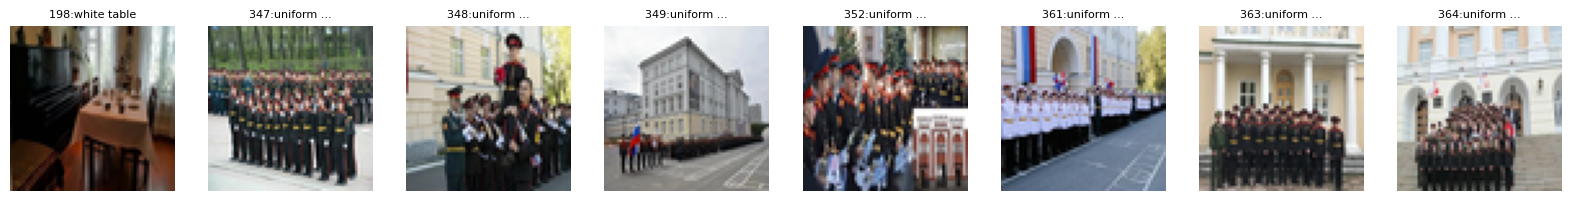

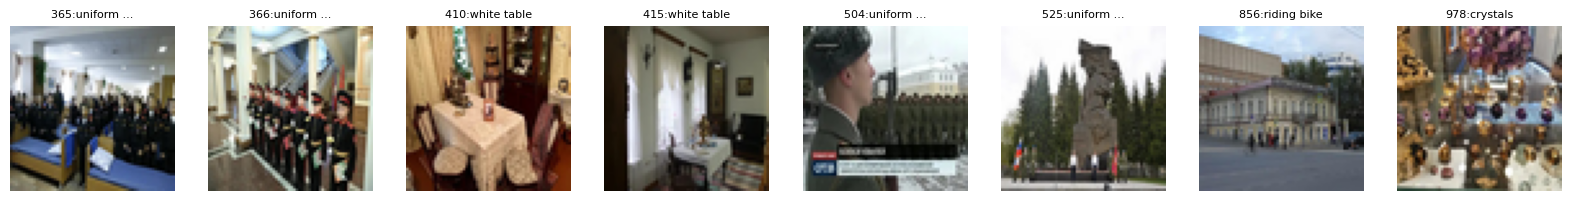

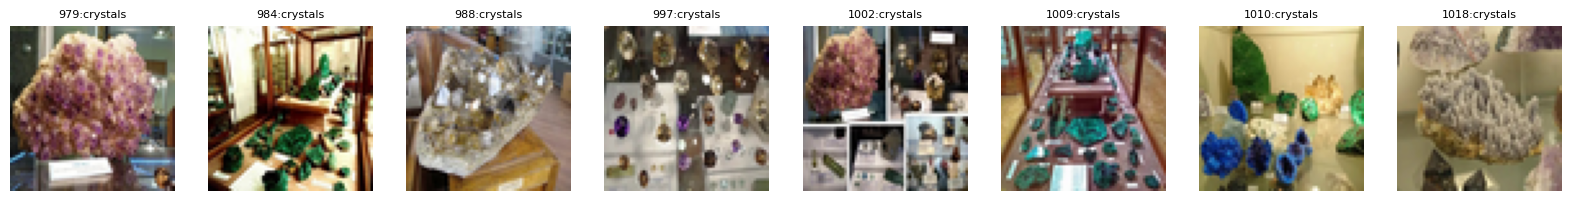

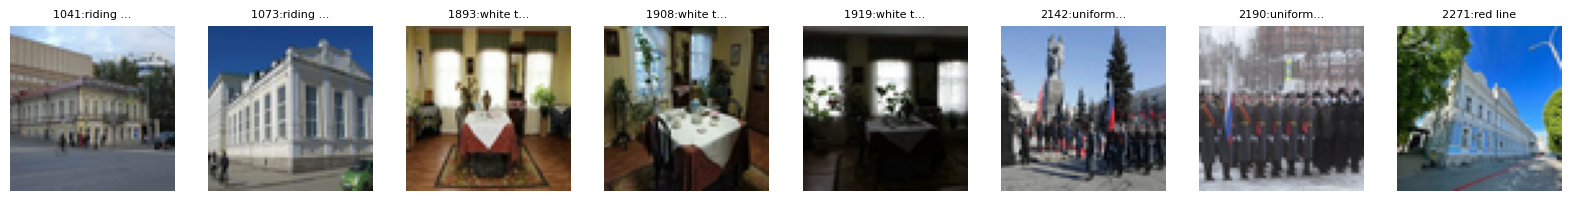

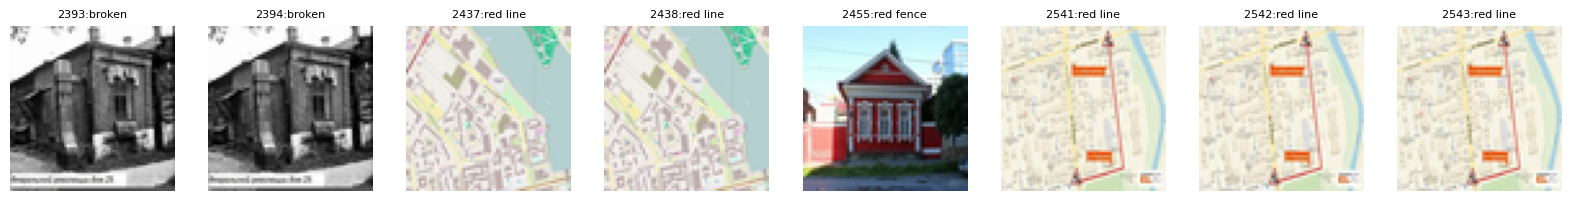

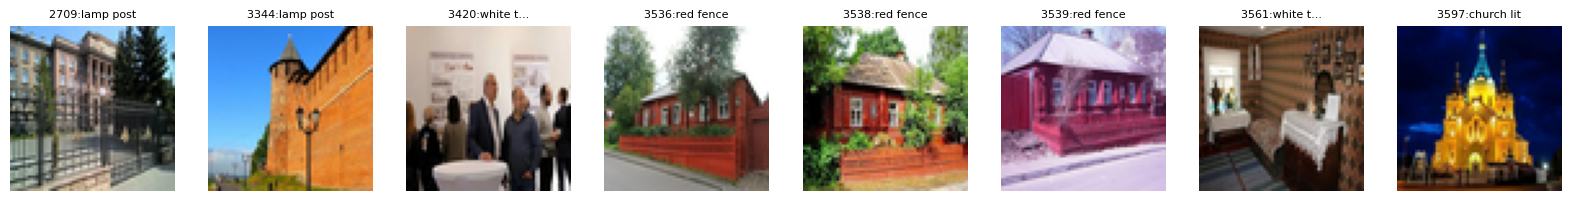

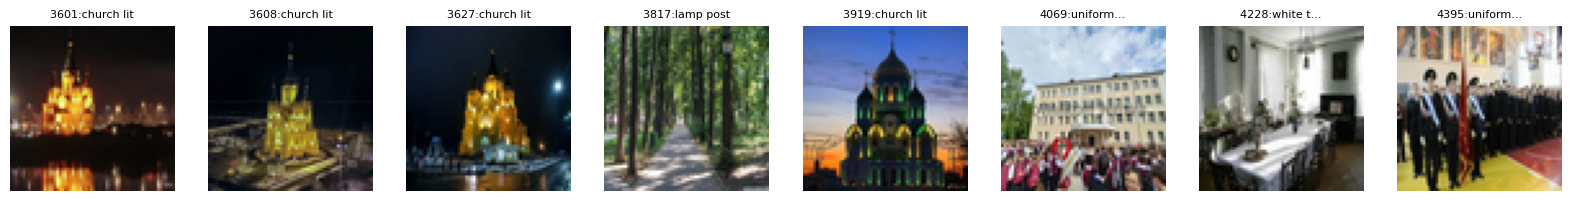

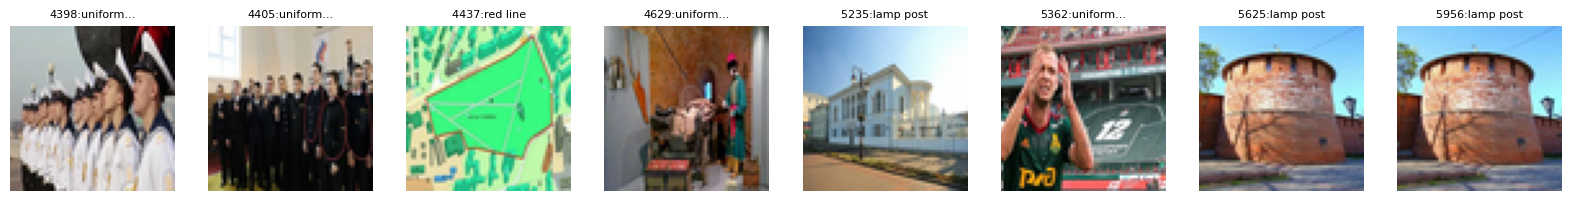

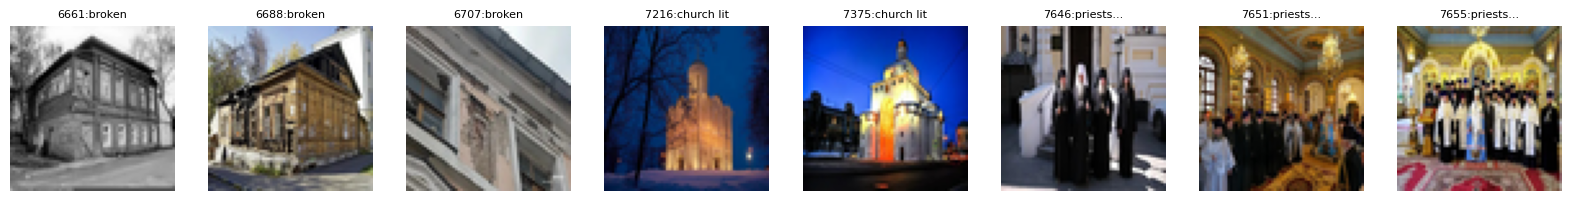

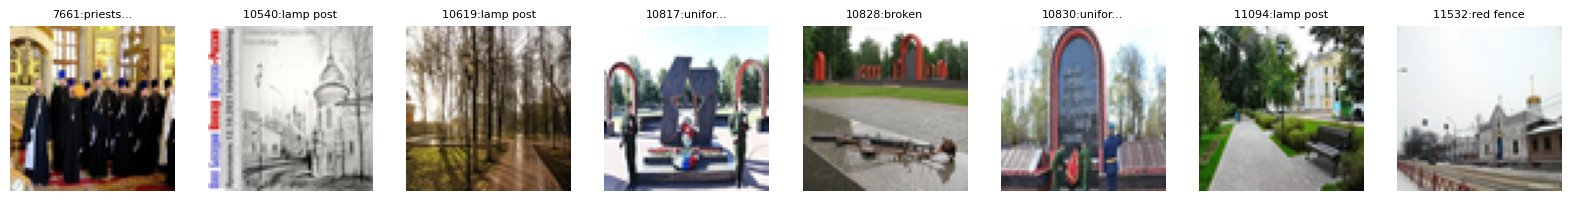

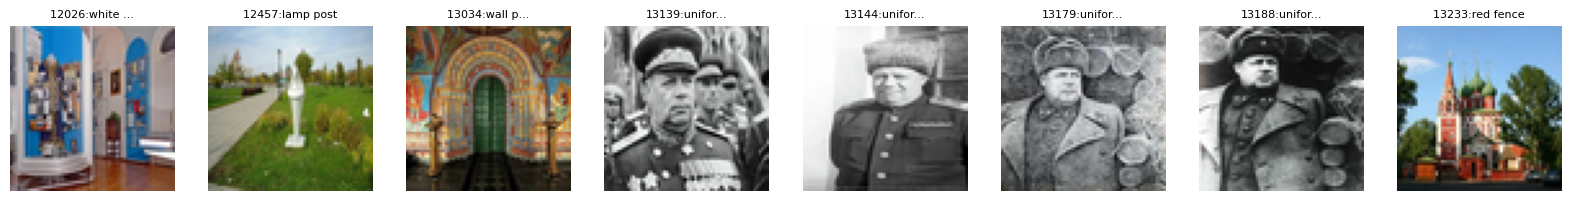

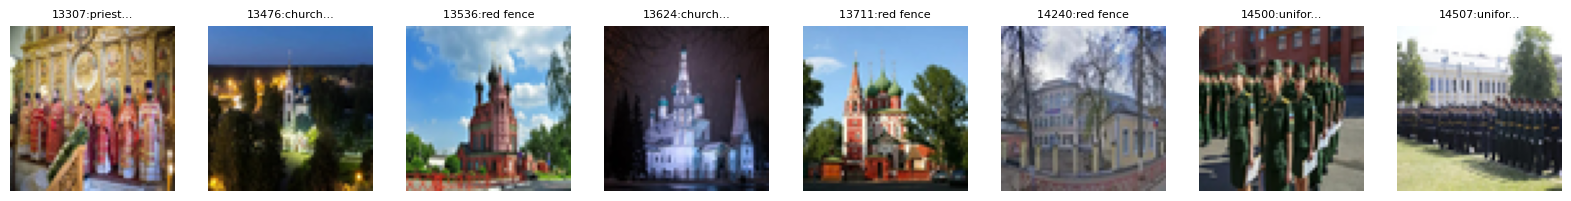

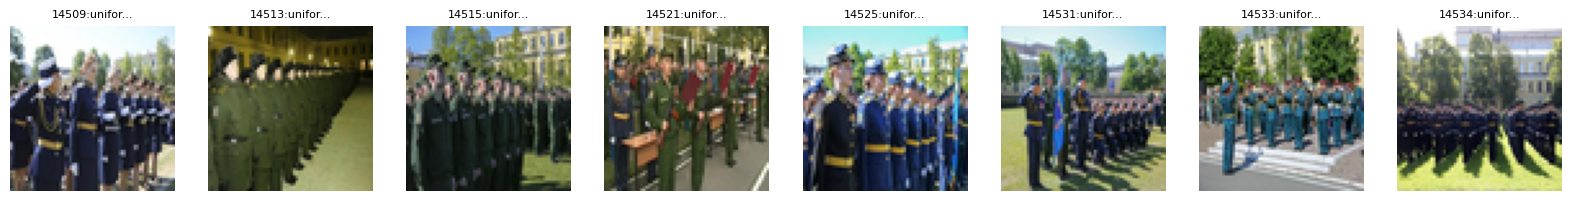

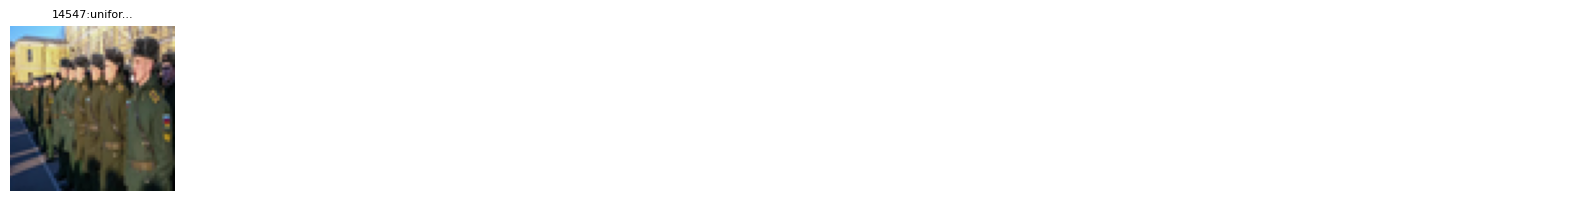

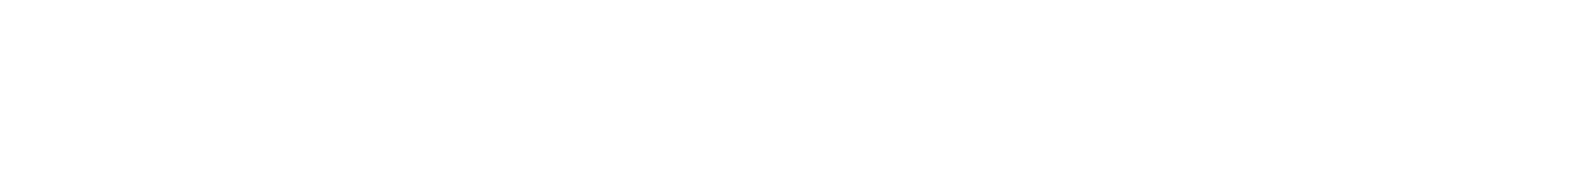

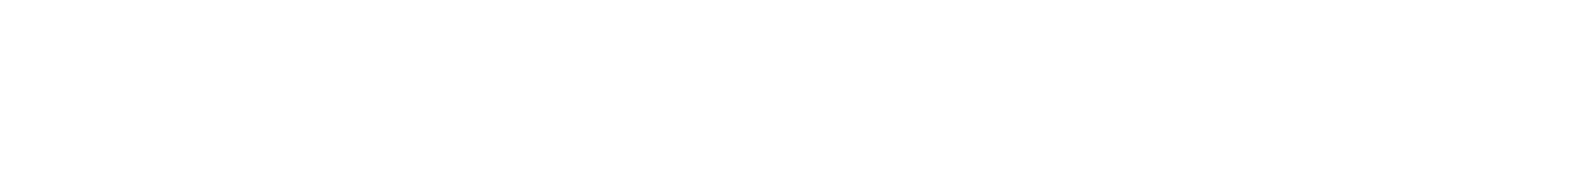

In [91]:
show_image_blocks_8x1(df[df['is_junc_words']], num_blocks=16)

> Эти данные безболезнено можно удалить - они слабо относятся к достопримечательностям города.

In [92]:
df = df[~df['is_junc_words']]

# Отбор 100

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [94]:
type_freq = ['дом', 'церковь', 'музей', 'памятник', 'собор', 'башня', 'театр',
             'улица', 'парк', 'монастырь', 'усадьба', 'университет', 'мост',
             'храм']
type_rare = ['сад', 'сквер', 'гостиница', 'стадион', 'зоопарк', 'цирк',
             'планетарий']

есть набор df

df.info()
```
<class 'pandas.core.frame.DataFrame'>
Index: 12078 entries, 0 to 14633
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Num          12078 non-null  int64
 1   Name         12078 non-null  object
 2   WikiData     12078 non-null  object
 3   City         12078 non-null  object
 4   Lon          12078 non-null  float64
 5   Lat          12078 non-null  float64
 6   description  12078 non-null  object
 7   image        12078 non-null  object
 8   en_txt       12078 non-null  object
dtypes: float64(2), int64(1), object(6)
memory usage: 943.6+ KB
df.City.unique()
array(['Екатеринбург', 'Нижний Новгород', 'Владимир', 'Ярославль'],
      dtype=object)
```

надо отобрать 150 записей со страфикацией по каждому городу и названию Name.
```
type_freq = ['дом', 'церковь', 'музей', 'памятник', 'собор', 'башня', 'театр',
             'улица', 'парк', 'монастырь', 'усадьба', 'университет', 'мост',
             'храм']
type_rare = ['сад', 'сквер', 'гостиница', 'стадион', 'зоопарк', 'цирк',
             'планетарий']
```
поле description должно содержать частые названия типа достопримечательности из списка type_freq и единичные из списка type_rare

выбрать наиболее представимые по длине описания


Добавим поле тип объекта и длину описания

In [95]:
import pandas as pd
import numpy as np


# Функция для определения типа достопримечательности по названию
def get_attraction_type(name):
    name_lower = name.lower()

    # Сначала проверяем редкие типы
    for rare_type in type_rare:
        if rare_type in name_lower:
            return rare_type

    # Затем частые типы
    for freq_type in type_freq:
        if freq_type in name_lower:
            return freq_type

    return 'other'


# Добавляем столбец с типом достопримечательности
df['attraction_type'] = df['description'].apply(get_attraction_type)


# Функция для вычисления длины описания (учитываем только русские символы)
def count_russian_chars(text):
    russian_letters = set('абвгдеёжзийклмнопрстуфхцчшщъыьэюя')
    return sum(1 for char in str(text).lower() if char in russian_letters)


df['description_length'] = df['description'].apply(count_russian_chars)

# Фильтруем только нужные типы (исключаем 'other')
valid_types = type_freq + type_rare
df_filtered = df[df['attraction_type'].isin(valid_types)].copy()

In [96]:
df_filtered[df_filtered['City'] == 'Ярославль'][
    'attraction_type'].value_counts()

attraction_type
храм         830
памятник     458
монастырь    316
церковь      255
музей        238
дом          228
парк         155
башня        145
театр        145
сад           84
собор         69
зоопарк       57
цирк          39
мост          29
Name: count, dtype: int64

Проведем выборку объектов в комбинации City+Name и распределенном по типу объекта

In [97]:
def stratified_sample(df, n_total=150):
    cities = df['City'].unique()
    samples_per_city = n_total // len(cities)

    sampled_dfs = []
    used_combinations = set()  # Множество для отслеживания использованных комбинаций City+Name

    for city in cities:
        city_df = df[df['City'] == city]

        # Распределяем выборку по типам внутри города
        types_in_city = city_df['attraction_type'].unique()
        base_samples_per_type = samples_per_city // len(types_in_city)
        remainder = samples_per_city % len(types_in_city)

        city_samples = []

        for i, attr_type in enumerate(types_in_city):
            type_df = city_df[city_df['attraction_type'] == attr_type]

            # Определяем сколько брать из этого типа
            n_samples = base_samples_per_type
            if i < remainder:
                n_samples += 1

            if len(type_df) >= n_samples:
                # Выбираем наиболее представительные по длине описания
                median_length = type_df['description_length'].median()
                type_df = type_df.copy()
                type_df['length_diff'] = abs(
                    type_df['description_length'] - median_length)

                # Сортируем по репрезентативности и выбираем уникальные имена
                sampled_type = type_df.sort_values('length_diff')

                # Фильтруем уже использованные комбинации и берем уникальные имена
                unique_samples = []
                for _, row in sampled_type.iterrows():
                    combination = (row['City'], row['Name'])
                    if combination not in used_combinations:
                        unique_samples.append(row)
                        used_combinations.add(combination)
                    if len(unique_samples) >= n_samples:
                        break

                sampled_type = pd.DataFrame(unique_samples)
            else:
                # Если записей меньше, чем нужно, берем все уникальные
                unique_samples = []
                for _, row in type_df.iterrows():
                    combination = (row['City'], row['Name'])
                    if combination not in used_combinations:
                        unique_samples.append(row)
                        used_combinations.add(combination)
                sampled_type = pd.DataFrame(unique_samples)

            city_samples.append(sampled_type)

        # Фильтруем пустые DataFrame
        city_samples = [sample for sample in city_samples if not sample.empty]
        if city_samples:
            sampled_dfs.extend(city_samples)

    result_df = pd.concat(sampled_dfs,
                          ignore_index=True) if sampled_dfs else pd.DataFrame()

    # Если общее количество не равно n_total, делаем корректировку
    if len(result_df) > n_total:
        # Удаляем лишние записи, начиная с наименее репрезентативных
        result_df = result_df.nlargest(n_total, 'description_length')
    elif len(result_df) < n_total:
        # Добавляем недостающие записи из наиболее репрезентативных
        additional_needed = n_total - len(result_df)
        remaining_df = df.copy()

        # Создаем маску для исключения уже использованных комбинаций
        mask = remaining_df.apply(
            lambda row: (row['City'], row['Name']) not in used_combinations,
            axis=1)
        available_df = remaining_df[mask]

        if not available_df.empty:
            additional_samples = available_df.nlargest(additional_needed,
                                                       'description_length')
            result_df = pd.concat([result_df, additional_samples],
                                  ignore_index=True)

    # Финальная проверка уникальности
    duplicates = result_df.duplicated(subset=['City', 'Name']).sum()
    if duplicates > 0:
        print(
            f"Предупреждение: в итоговой выборке найдено {duplicates} дубликатов. Удаляем...")
        result_df = result_df.drop_duplicates(subset=['City', 'Name'])

    print(f"Итоговый размер выборки: {len(result_df)} записей")
    print(
        f"Уникальных комбинаций City+Name: {result_df[['City', 'Name']].drop_duplicates().shape[0]}")

    return result_df

In [98]:
# Выполняем стратифицированную выборку
sampled_df = stratified_sample(df_filtered, 150)

Предупреждение: в итоговой выборке найдено 30 дубликатов. Удаляем...
Итоговый размер выборки: 120 записей
Уникальных комбинаций City+Name: 120


Проверяем распределение

In [99]:
print("Распределение по городам:")
print(sampled_df['City'].value_counts())
print("\nРаспределение по типам достопримечательностей:")
print(sampled_df['attraction_type'].value_counts())

# Удаляем вспомогательные столбцы
# sampled_df = sampled_df.drop(['attraction_type', 'description_length'], axis=1)

print(f"\nИтоговый размер выборки: {len(sampled_df)} записей")

Распределение по городам:
City
Нижний Новгород    36
Екатеринбург       32
Ярославль          32
Владимир           20
Name: count, dtype: int64

Распределение по типам достопримечательностей:
attraction_type
храм           13
музей          13
дом            11
памятник       11
церковь        11
театр           9
монастырь       9
собор           8
парк            7
башня           7
сад             7
университет     3
мост            3
стадион         2
улица           2
гостиница       1
планетарий      1
цирк            1
зоопарк         1
Name: count, dtype: int64

Итоговый размер выборки: 120 записей


In [100]:
sampled_df

,Num,Name,WikiData,City,Lon,Lat,description,image,en_txt,is_junc_words,found_text,attraction_type,description_length,length_diff
0,2372,Доходный дом купца Чувильдина,Q27921892,Екатеринбург,60.607727,56.832176,Дом купца Чувильдина,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large building with a clock on the ...,False,None,дом,18,0.0
1,2219,№29 Дом В.И. Чувильдина,Q27921892,Екатеринбург,60.607689,56.832268,Дом купца Чувильдина,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large building with a clock on top ...,False,None,дом,18,0.0
2,2318,Дом Актёра,Q4165449,Екатеринбург,60.597950,56.838634,Дом актёра (Екатеринбург),/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,nighttime shot of a building with stairs and t...,False,None,дом,21,3.0
3,993,Уральский геологический музей,Q4476747,Екатеринбург,60.595470,56.826492,музей в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large rock sitting on a wooden tabl...,False,None,музей,19,0.0
4,1661,Музей истории Екатеринбурга,Q4306294,Екатеринбург,60.611423,56.840691,музей в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed room with a large display of old photos...,False,None,музей,19,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2773,Успенский собор,Q1140551,Ярославль,39.901978,57.622429,кафедральный собор в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a large white building with gol...,False,None,собор,27,0.0
116,4043,Ярославская соборная мечеть,Q4281966,Ярославль,39.875633,57.636059,Ярославская соборная мечеть,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a small pond in front of a building w...,False,None,собор,25,2.0
117,3851,Цирк,Q4538876,Ярославль,39.865444,57.625584,Ярославский государственный цирк,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large building with a sign on the f...,False,None,цирк,30,0.0
118,4114,Ярославский зоопарк,Q16723452,Ярославль,39.895737,57.674446,Ярославский зоопарк,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large teddy bear sitting on top of ...,False,None,зоопарк,18,0.0


In [101]:
sampled_df[sampled_df['City'] == 'Ярославль']['attraction_type'].value_counts()

attraction_type
храм         3
церковь      3
дом          3
башня        3
памятник     3
монастырь    3
музей        3
сад          2
парк         2
театр        2
собор        2
мост         1
цирк         1
зоопарк      1
Name: count, dtype: int64

In [102]:
sampled_df[sampled_df['City'] == 'Нижний Новгород'][
    'attraction_type'].value_counts()

attraction_type
дом          4
башня        4
памятник     3
театр        3
собор        3
музей        3
парк         3
храм         3
церковь      3
монастырь    3
сад          3
стадион      1
Name: count, dtype: int64

# Формирование расширенного контекста документов

Выведем формальное описание в файл в формате markdown и прогоним через LLM для перевода и насыщения контекста

In [103]:
sampled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 0 to 119
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Num                 120 non-null    int64  
 1   Name                120 non-null    object 
 2   WikiData            120 non-null    object 
 3   City                120 non-null    object 
 4   Lon                 120 non-null    float64
 5   Lat                 120 non-null    float64
 6   description         120 non-null    object 
 7   image               120 non-null    object 
 8   en_txt              120 non-null    object 
 9   is_junc_words       120 non-null    bool   
 10  found_text          0 non-null      object 
 11  attraction_type     120 non-null    object 
 12  description_length  120 non-null    int64  
 13  length_diff         119 non-null    float64
dtypes: bool(1), float64(3), int64(2), object(8)
memory usage: 13.2+ KB


In [104]:
sampled_df[
    ['City', 'attraction_type', 'Name', 'description', 'en_txt', 'Lon', 'Lat',
     'WikiData']]

,City,attraction_type,Name,description,en_txt,Lon,Lat,WikiData
0,Екатеринбург,дом,Доходный дом купца Чувильдина,Дом купца Чувильдина,there is a large building with a clock on the ...,60.607727,56.832176,Q27921892
1,Екатеринбург,дом,№29 Дом В.И. Чувильдина,Дом купца Чувильдина,there is a large building with a clock on top ...,60.607689,56.832268,Q27921892
2,Екатеринбург,дом,Дом Актёра,Дом актёра (Екатеринбург),nighttime shot of a building with stairs and t...,60.597950,56.838634,Q4165449
3,Екатеринбург,музей,Уральский геологический музей,музей в Екатеринбурге,there is a large rock sitting on a wooden tabl...,60.595470,56.826492,Q4476747
4,Екатеринбург,музей,Музей истории Екатеринбурга,музей в Екатеринбурге,arafed room with a large display of old photos...,60.611423,56.840691,Q4306294
...,...,...,...,...,...,...,...,...
115,Ярославль,собор,Успенский собор,кафедральный собор в Ярославле,arafed view of a large white building with gol...,39.901978,57.622429,Q1140551
116,Ярославль,собор,Ярославская соборная мечеть,Ярославская соборная мечеть,there is a small pond in front of a building w...,39.875633,57.636059,Q4281966
117,Ярославль,цирк,Цирк,Ярославский государственный цирк,there is a large building with a sign on the f...,39.865444,57.625584,Q4538876
118,Ярославль,зоопарк,Ярославский зоопарк,Ярославский зоопарк,there is a large teddy bear sitting on top of ...,39.895737,57.674446,Q16723452


In [117]:
def print_records_compact(df, file=None):
    """
    Компактная версия процедуры печати записей
    file: файловый объект или None (по умолчанию - консоль)
    """
    print(f"\nВЫВОД ЗАПИСЕЙ (всего: {len(df)})", file=file)
    print("=" * 60, file=file)

    for index, row in df.iterrows():
        print(f"\n Индекс[{index}] {row['Name']}", file=file)
        print(f"   Город: {row['City']} | Тип: {row['attraction_type']}",
              file=file)
        print(f"   Координаты: {row['Lon']}, {row['Lat']}", file=file)
        print(f"   Описание: {row['description']}", file=file)
        print(f"   Описание изображения (анг): {row['en_txt']}", file=file)
        print(f"   Wikidata: {row['WikiData']}", file=file)

In [120]:
print_records_compact(sampled_df.head(5))


ВЫВОД ЗАПИСЕЙ (всего: 5)

 Индекс[0] Доходный дом купца Чувильдина
   Город: Екатеринбург | Тип: дом
   Координаты: 60.607727, 56.832176
   Описание: Дом купца Чувильдина
   Описание изображения (анг): there is a large building with a clock on the top of it
   Wikidata: Q27921892

 Индекс[1] №29 Дом В.И. Чувильдина
   Город: Екатеринбург | Тип: дом
   Координаты: 60.607689, 56.832268
   Описание: Дом купца Чувильдина
   Описание изображения (анг): there is a large building with a clock on top of it
   Wikidata: Q27921892

 Индекс[2] Дом Актёра
   Город: Екатеринбург | Тип: дом
   Координаты: 60.59795, 56.838634
   Описание: Дом актёра (Екатеринбург)
   Описание изображения (анг): nighttime shot of a building with stairs and trees in the foreground
   Wikidata: Q4165449

 Индекс[3] Уральский геологический музей
   Город: Екатеринбург | Тип: музей
   Координаты: 60.59547, 56.826492
   Описание: музей в Екатеринбурге
   Описание изображения (анг): there is a large rock sitting on a woode

In [121]:
with open('output.txt', 'w', encoding='utf-8') as f:
    print_records_compact(sampled_df, file=f)

> Сырые данные прогоняем через LLM для перевода и насыщения.

Сделай описание по данным ниже для системы RAG. английский перевести на русский
пример

Индекс: 34
Название: Царский мост
Тип объекта: Мост
Локация: Город Екатеринбург, Россия
Координаты: 60.613163, 56.823517
Функция: Пересекает реку Исеть, обеспечивая автомобильное и пешеходное сообщение между районами города.
Статус: Объект культурного наследия и важный исторический памятник.
Идентификатор во внешней БД: Wikidata (Q4503250)

In [106]:
import pandas as pd


def parse_file_simple(filename):
    with open(filename, 'r', encoding='utf-8') as file:
        content = file.read()

    records = content.split('---')
    data = []

    for record in records:
        record = record.strip()
        if not record:
            continue

        lines = record.split('\n')
        num = None
        text_lines = []

        for line in lines:
            line = line.strip()
            if line.startswith('**Индекс:'):
                # Извлекаем число после "Индекс:"
                num_str = line.replace('**Индекс:', '').replace('**',
                                                                '').strip()
                num = int(num_str)
            elif line:
                text_lines.append(line)

        if num is not None:
            data.append({'num': num, 'text': '\n'.join(text_lines)})

    df = pd.DataFrame(data)
    df = df.set_index('num')
    return df

In [107]:
# Использование
dfs = parse_file_simple('whole_context.md')

In [108]:
dfs.head()

,text
num,
0,**Название:** Доходный дом купца Чувильдина\n*...
1,**Название:** №29 Дом В.И. Чувильдина\n**Тип о...
2,**Название:** Дом Актёра\n**Тип объекта:** Дом...
3,**Название:** Уральский геологический музей\n*...
4,**Название:** Музей истории Екатеринбурга\n**Т...


In [110]:
dfs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 0 to 119
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    120 non-null    object
dtypes: object(1)
memory usage: 1.9+ KB


In [111]:
sampled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 0 to 119
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Num                 120 non-null    int64  
 1   Name                120 non-null    object 
 2   WikiData            120 non-null    object 
 3   City                120 non-null    object 
 4   Lon                 120 non-null    float64
 5   Lat                 120 non-null    float64
 6   description         120 non-null    object 
 7   image               120 non-null    object 
 8   en_txt              120 non-null    object 
 9   is_junc_words       120 non-null    bool   
 10  found_text          0 non-null      object 
 11  attraction_type     120 non-null    object 
 12  description_length  120 non-null    int64  
 13  length_diff         119 non-null    float64
dtypes: bool(1), float64(3), int64(2), object(8)
memory usage: 13.2+ KB


In [112]:
# Связываем датафреймы по индексу и добавляем нужные поля
dfs = dfs.join(sampled_df[['City', 'Name', 'Lon', 'Lat', 'image']])

In [123]:
dfs

,text,City,Name,Lon,Lat,image
num,,,,,,
0,**Название:** Доходный дом купца Чувильдина\n*...,Екатеринбург,Доходный дом купца Чувильдина,60.607727,56.832176,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...
1,**Название:** №29 Дом В.И. Чувильдина\n**Тип о...,Екатеринбург,№29 Дом В.И. Чувильдина,60.607689,56.832268,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...
2,**Название:** Дом Актёра\n**Тип объекта:** Дом...,Екатеринбург,Дом Актёра,60.597950,56.838634,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...
3,**Название:** Уральский геологический музей\n*...,Екатеринбург,Уральский геологический музей,60.595470,56.826492,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...
4,**Название:** Музей истории Екатеринбурга\n**Т...,Екатеринбург,Музей истории Екатеринбурга,60.611423,56.840691,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...
...,...,...,...,...,...,...
115,**Название:** Успенский собор\n**Тип объекта:*...,Ярославль,Успенский собор,39.901978,57.622429,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...
116,**Название:** Ярославская соборная мечеть\n**Т...,Ярославль,Ярославская соборная мечеть,39.875633,57.636059,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...
117,**Название:** Цирк\n**Тип объекта:** Цирк\n**Л...,Ярославль,Цирк,39.865444,57.625584,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...


> Корпус документов с метаданными сформирован

In [120]:
dfs.to_pickle('doc_source.pkl')

In [122]:
dfs = pd.read_pickle('doc_source.pkl')

# RAG

In [1]:
import pandas as pd

dfs = pd.read_pickle('doc_source.pkl')


Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

In [2]:
from langchain_core.documents import Document as LangchainDocument

RAW_KNOWLEDGE_BASE = [LangchainDocument(page_content=row["text"],
                                        metadata={"City": row["City"],
                                                  "Lon": row["Lon"],
                                                  "Lat": row["Lat"],
                                                  "image": row["image"]}) for
                      index, row in dfs.iterrows()]

Для токенизации и создания ембеддингов будем использовать `cointegrated/rubert-tiny2` https://huggingface.co/cointegrated/rubert-tiny2

In [3]:
from sentence_transformers import SentenceTransformer

print(
    f"Model's maximum sequence length: {SentenceTransformer('cointegrated/rubert-tiny2').max_seq_length}")


Model's maximum sequence length: 2048


Предварительно этого окна достаточно для всех документов

In [4]:
# from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Мы используем иерархический список разделителей, специально предназначенных для разделения документов Markdown
# Этот список взят из класса MarkdownTextSplitter в LangChain

MARKDOWN_SEPARATORS = ["\n#{1,6} ", "```\n", "\n\\*\\*\\*+\n", "\n---+\n",
                       "\n___+\n", "\n\n", "\n", " ", "", ]

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000,
                                               # Максимальное количество символов в чанке
                                               chunk_overlap=100,
                                               # Количество символов, которые будут перекрываться между чанками
                                               add_start_index=True,
                                               # Если "True", то включает начальный индекс чанка в метаданные
                                               strip_whitespace=True,
                                               # Если значение "True", то пробелы удаляются из начала и конца каждого документа
                                               # separators=MARKDOWN_SEPARATORS,
                                               )

docs_processed = []
for doc in RAW_KNOWLEDGE_BASE:
    docs_processed += text_splitter.split_documents([doc])

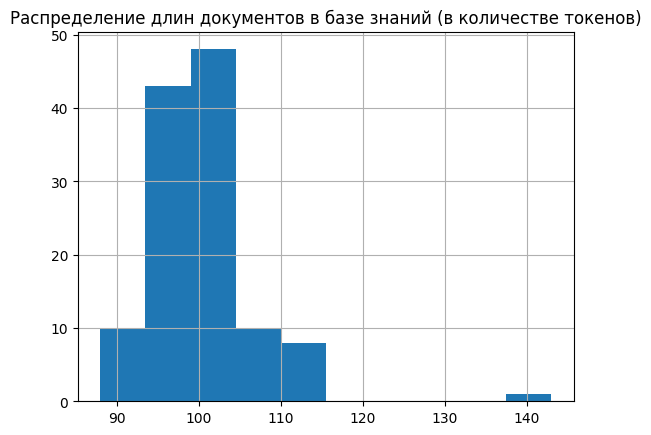

In [40]:
from matplotlib import pyplot as plt
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")
lengths = [len(tokenizer.encode(doc.page_content)) for doc in docs_processed]

# Построим график распределения длин документов, подсчитываемых как количество токенов
fig = pd.Series(lengths).hist()
plt.title("Распределение длин документов в базе знаний (в количестве токенов)")
plt.show()

### Основная процедура сплита документов

In [39]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import Optional, List, Tuple

from transformers import AutoTokenizer

EMBEDDING_MODEL_NAME = "cointegrated/rubert-tiny2"


def split_documents(chunk_size: int, knowledge_base: List[LangchainDocument],
                    tokenizer_name: Optional[str] = EMBEDDING_MODEL_NAME, ) -> \
        List[LangchainDocument]:
    """
    Разобъём документы на блоки максимального размера `chunk_size` и вернём список документов.
    """
    text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        AutoTokenizer.from_pretrained(tokenizer_name), chunk_size=chunk_size,
        chunk_overlap=int(chunk_size / 10), add_start_index=True,
        strip_whitespace=True,  # separators=MARKDOWN_SEPARATORS,
    )

    docs_processed = []
    for doc in knowledge_base:
        docs_processed += text_splitter.split_documents([doc])

    # Удалим дубли
    unique_texts = {}
    docs_processed_unique = []
    for doc in docs_processed:
        if doc.page_content not in unique_texts:
            unique_texts[doc.page_content] = True
            docs_processed_unique.append(doc)

    return docs_processed_unique


In [7]:
docs_processed = split_documents(2048,
                                 # Выбираем размер чанка, соответствующий модели
                                 RAW_KNOWLEDGE_BASE,
                                 tokenizer_name=EMBEDDING_MODEL_NAME, )

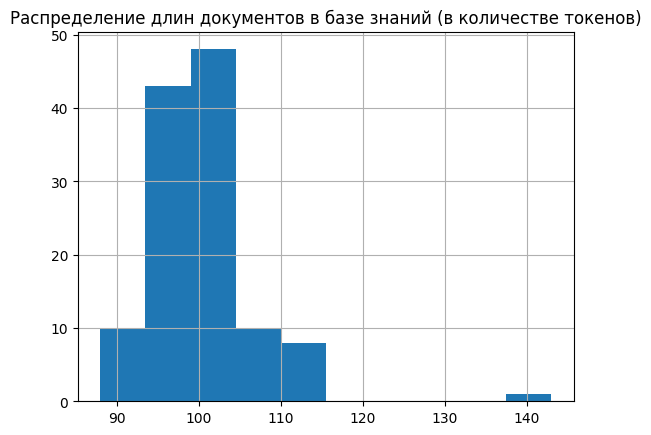

In [13]:
# Представим размеры блоков, которые возможно получить в токенах из общей модели
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)
lengths = [len(tokenizer.encode(doc.page_content)) for doc in docs_processed]
fig = pd.Series(lengths).hist()
plt.title("Распределение длин документов в базе знаний (в количестве токенов)")
plt.show()

Обертка для langchain

In [12]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL_NAME,
                                        multi_process=True,
                                        # model_kwargs={"device": "cuda"},
                                        encode_kwargs={
                                            "normalize_embeddings": True},
                                        # `True` для косинусного сходства
                                        )

### Векторная база Chroma

In [8]:
from langchain_chroma import Chroma
from tqdm import tqdm

In [ ]:

# Создаем базу данных
documents_with_progress = tqdm(docs_processed, desc="Creating embeddings")

KNOWLEDGE_VECTOR_DATABASE = Chroma.from_documents(
    documents=list(documents_with_progress), embedding=embedding_model,
    persist_directory="./chroma_db",
    collection_metadata={"hnsw:space": "cosine"}
    # Указываем косинусное расстояние
)

In [13]:
KNOWLEDGE_VECTOR_DATABASE = Chroma(persist_directory="./chroma_db",
                                   embedding_function=embedding_model)
print("Vector database loaded from './chroma_db'")

Vector database loaded from './chroma_db'


In [14]:
# Получение информации о коллекции
print(f"Collection count: {KNOWLEDGE_VECTOR_DATABASE._collection.count()}")

Collection count: 120


In [15]:
import chromadb

# Подключаемся к существующей базе
client = chromadb.PersistentClient(path="./chroma_db")

# Получаем список всех коллекций
collections = client.list_collections()
print(f"Найдено коллекций: {len(collections)}")


Найдено коллекций: 1


In [160]:
if False:
    for collection in collections:
        client.delete_collection(collection.name)
        print(f"Коллекция удалена: {collection.name}")

    print("Все коллекции удалены")

Коллекция удалена: langchain
Все коллекции удалены


### Тестирование векторной БД

In [21]:
# Поиск похожих документов
results = KNOWLEDGE_VECTOR_DATABASE.similarity_search("дом в городе владимир",
                                                      k=5)

In [23]:
for res in results:
    print('=' * 20)
    print(res.page_content)

**Название:** Владимирский академический областной драматический театр
**Тип объекта:** Театр
**Локация:** Город Владимир, Россия
**Координаты:** 40.396076, 56.125618
**Описание:** театр города Владимира
**Описание изображения:** большое здание с множеством окон
**Идентификатор во внешней БД:** Wikidata (Q56230588)
**Название:** Доходный дом купца Чувильдина
**Тип объекта:** Дом
**Локация:** Город Екатеринбург, Россия
**Координаты:** 60.607727, 56.832176
**Описание:** Дом купца Чувильдина
**Описание изображения:** большое здание с часами наверху
**Идентификатор во внешней БД:** Wikidata (Q27921892)
**Название:** №29 Дом В.И. Чувильдина
**Тип объекта:** Дом
**Локация:** Город Екатеринбург, Россия
**Координаты:** 60.607689, 56.832268
**Описание:** Дом купца Чувильдина
**Описание изображения:** большое здание с часами наверху
**Идентификатор во внешней БД:** Wikidata (Q27921892)
**Название:** Дом Виноградовых
**Тип объекта:** Дом
**Локация:** Город Нижний Новгород, Россия
**Координаты:** 

In [18]:
user_query = "дом в городе владимир"
query_vector = embedding_model.embed_query(user_query)

In [181]:
len(docs_processed)

120

In [182]:
docs_processed[0].page_content

'**Название:** Доходный дом купца Чувильдина\n**Тип объекта:** Дом\n**Локация:** Город Екатеринбург, Россия\n**Координаты:** 60.607727, 56.832176\n**Описание:** Дом купца Чувильдина\n**Описание изображения:** большое здание с часами наверху\n**Идентификатор во внешней БД:** Wikidata (Q27921892)'

> В выборке есть дома из Владимира, но не на первом месте. Необходимо их отранжировать.

### Визуализация PCA

Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [20]:
def get_all_embeddings_from_db(vectorstore):
    """Быстро получает эмбеддинги напрямую из базы данных"""
    try:
        # Пытаемся получить коллекцию и эмбеддинги
        collection = vectorstore._collection
        results = collection.get(include=['embeddings'])

        if 'embeddings' in results and results['embeddings']:
            embeddings_array = np.array(results['embeddings'])
            print(f"Загружено {len(embeddings_array)} эмбеддингов из базы")
            return embeddings_array
        else:
            print("Эмбеддинги не найдены в базе, вычисляем заново...")
            return None
    except Exception as e:
        print(f"Ошибка при загрузке эмбеддингов из базы: {e}")
        return None


def get_all_embeddings_fast(vectorstore, docs_processed, query_vector=None):
    """Оптимизированная версия получения эмбеддингов"""
    # Пытаемся загрузить из базы
    embeddings_array = get_all_embeddings_from_db(vectorstore)

    # Если не получилось, вычисляем с оптимизацией
    if embeddings_array is None:
        print("Вычисляем эмбеддинги...")
        doc_embeddings = []

        # Обрабатываем батчами для ускорения
        batch_size = 32
        for i in tqdm(range(0, len(docs_processed), batch_size)):
            batch_docs = docs_processed[i:i + batch_size]
            batch_texts = [doc.page_content for doc in batch_docs]

            try:
                batch_embeddings = vectorstore._embedding_function.embed_documents(
                    batch_texts)
                doc_embeddings.extend(batch_embeddings)
            except Exception as e:
                print(f"Ошибка в батче {i}: {e}")
                continue

        embeddings_array = np.array(doc_embeddings)

    return embeddings_array

In [21]:
all_embeddings = get_all_embeddings_fast(KNOWLEDGE_VECTOR_DATABASE,
                                         docs_processed, query_vector)

Ошибка при загрузке эмбеддингов из базы: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()
Вычисляем эмбеддинги...


100%|██████████| 4/4 [01:26<00:00, 21.66s/it]


In [23]:
query_array = np.array(query_vector)
if len(query_array.shape) == 1:
    query_array = query_array.reshape(1, -1)
embeddings_array = np.vstack([all_embeddings, query_array])

In [24]:
embeddings_array.shape

(121, 312)

In [30]:
# Создаем метки для точек
labels = [f"Doc_{i}_{docs_processed[i].metadata['City']}" for i in
          range(len(docs_processed))]

# Определяем тип точек
doc_types = ['document'] * len(docs_processed)

# Если есть вектор запроса, добавляем его к данным
if query_vector is not None:
    labels.append("Query")
    doc_types.append('query')

# Проверяем соответствие размеров
print(f"Документов: {len(docs_processed)}")
print(f"Query присутствует: {query_vector is not None}")
print(f"Размер all_embeddings: {embeddings_array.shape}")
print(f"Длина labels: {len(labels)}")
print(f"Длина doc_types: {len(doc_types)}")

Документов: 120
Query присутствует: True
Размер all_embeddings: (121, 312)
Длина labels: 121
Длина doc_types: 121


In [31]:
# Метод 1: PCA визуализация
print("=== PCA Визуализация ===")
pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(embeddings_array)

# Создаем DataFrame для Plotly
pca_df = pd.DataFrame(
    {'x': embeddings_pca[:, 0], 'y': embeddings_pca[:, 1], 'label': labels,
     'type': doc_types})

# Визуализация PCA
fig_pca = px.scatter(pca_df, x='x', y='y', color='type',
                     title='PCA Projection of Embeddings',
                     labels={'x': 'PC1', 'y': 'PC2'}, hover_data=['label'],
                     color_discrete_map={'document': 'blue', 'query': 'red'})
fig_pca.update_traces(marker=dict(size=10, opacity=0.7))
fig_pca.show()

=== PCA Визуализация ===


### Визуализация TSNE

In [28]:
from sklearn.manifold import TSNE

# Метод 2: t-SNE визуализация
print("=== t-SNE Визуализация ===")
tsne = TSNE(n_components=2, random_state=42,
            perplexity=min(30, len(embeddings_array) - 1))
embeddings_tsne = tsne.fit_transform(embeddings_array)

# Создаем DataFrame для t-SNE
tsne_df = pd.DataFrame(
    {'x': embeddings_tsne[:, 0], 'y': embeddings_tsne[:, 1], 'label': labels,
     'type': ['document'] * len(docs_processed) + (
         ['query'] if query_vector is not None else [])})

# Визуализация t-SNE
fig_tsne = px.scatter(tsne_df, x='x', y='y', color='type',
                      title='t-SNE Projection of Embeddings',
                      labels={'x': 't-SNE1', 'y': 't-SNE2'},
                      hover_data=['label'],
                      color_discrete_map={'document': 'green', 'query': 'red'})
fig_tsne.update_traces(marker=dict(size=10, opacity=0.7))
fig_tsne.show()

=== t-SNE Визуализация ===


### Визуализация SVD

In [29]:
# Метод 3: Truncated SVD
print("=== Truncated SVD Визуализация ===")
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=60)
embeddings_svd = svd.fit_transform(embeddings_array)

# Создаем DataFrame для SVD
svd_df = pd.DataFrame(
    {'x': embeddings_svd[:, 0], 'y': embeddings_svd[:, 1], 'label': labels,
     'type': ['document'] * len(docs_processed) + (
         ['query'] if query_vector is not None else [])})

# Визуализация SVD
fig_svd = px.scatter(svd_df, x='x', y='y', color='type',
                     title='Truncated SVD Projection of Embeddings',
                     labels={'x': 'SVD1', 'y': 'SVD2'}, hover_data=['label'],
                     color_discrete_map={'document': 'purple', 'query': 'red'})
fig_svd.update_traces(marker=dict(size=10, opacity=0.7))
fig_svd.show()

=== Truncated SVD Визуализация ===


> Для снижения размерности я использовал методы PCA, TSNE и SVD. Метод PCA уловил кластера и отобразил запрос отностительно релевантных объектов.

## Подключение LLM Gigachat

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

GIGACHAT_AUTH_KEY = os.getenv('GIGACHAT_AUTH_KEY')

print(GIGACHAT_AUTH_KEY)  # Проверка

In [36]:
from gigachat import GigaChat
from gigachat.models import Chat, Messages, MessagesRole


class GigaChatPipeline:
    def __init__(self, credentials, temperature=0.2, max_tokens=500):
        self.giga = GigaChat(credentials=credentials, verify_ssl_certs=False,
                             scope="GIGACHAT_API_PERS")
        self.temperature = temperature
        self.max_tokens = max_tokens

    def __call__(self, prompt):
        # Если промт - список сообщений (как в вашем формате)
        if isinstance(prompt, list):
            messages = self._convert_messages_format(prompt)
        # Если промт - строка (старый формат)
        elif isinstance(prompt, str):
            messages = [Messages(role=MessagesRole.USER, content=prompt)]
        else:
            raise ValueError("Prompt must be either string or list of messages")

        response = self.giga.chat(
            Chat(messages=messages, temperature=self.temperature,
                 max_tokens=self.max_tokens, ))

        return [{"generated_text": response.choices[0].message.content}]

    def _convert_messages_format(self, messages_list):
        """Конвертирует сообщения из формата HuggingFace в формат GigaChat"""
        gigachat_messages = []

        role_mapping = {"system": MessagesRole.SYSTEM,
                        "user": MessagesRole.USER,
                        "assistant": MessagesRole.ASSISTANT}

        for msg in messages_list:
            role = msg.get("role", "user")
            content = msg.get("content", "")

            gigachat_role = role_mapping.get(role, MessagesRole.USER)
            gigachat_messages.append(
                Messages(role=gigachat_role, content=content))

        return gigachat_messages


# Использование как замена pipeline
READER_LLM = GigaChatPipeline(credentials=GIGACHAT_AUTH_KEY, temperature=0.2,
                              max_tokens=500)

In [37]:
print(READER_LLM("What is 4+4? Answer:"))

[{'generated_text': '### Шаг 1: Понимание условия\nЗадача состоит в простом сложении двух чисел — 4 и 4.\n\n### Шаг 2: Выполнение операции сложения\nСложим числа:\n$$ 4 + 4 = 8 $$\n\n### Итоговый ответ:\n$4 + 4 = 8$'}]


## Формирование промпта

Приведенный ниже шаблон RAG — это то, что мы передадим в Reader LLM: важно, чтобы он был отформатирован в шаблоне чата Reader LLM. Мы даем ему наш контекст и вопрос пользователя.

In [62]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)

tokenizer.chat_template = """{% for message in messages %}
{% if message['role'] == 'user' %}
Human: {{ message['content'] }}
{% elif message['role'] == 'assistant' %}
Assistant: {{ message['content'] }}
{% elif message['role'] == 'system' %}
System: {{ message['content'] }}
{% endif %}
{% endfor %}
Assistant:"""

prompt_in_chat_format = [{"role": "system", "content": """
        Используя информацию, содержащуюся в контексте,дайте развернутый ответ на вопрос.
Отвечайте только на заданный вопрос, ответ должен быть кратким и соответствовать теме.
Опиши в свободной форме найденную достопримечательность.
Опиши как рассказывает экскурсовод. В конце приведи дополнительную информацию (1-2 предложения).
Избегай структуры.
Укажите номер исходного документа, если это необходимо.
Если ответ не может быть выведен из контекста, не давайте ответ.""", },
                         {"role": "user", "content": """Context:
{context}
---
А теперь вопрос, на который вам нужно ответить:

Вопрос: {question}""", }, ]

RAG_PROMPT_TEMPLATE = tokenizer.apply_chat_template(prompt_in_chat_format,
                                                    tokenize=False,
                                                    add_generation_prompt=True)
print(RAG_PROMPT_TEMPLATE)

System: 
        Используя информацию, содержащуюся в контексте,дайте развернутый ответ на вопрос.
Отвечайте только на заданный вопрос, ответ должен быть кратким и соответствовать теме.
Опиши в свободной форме найденную достопримечательность.
Опиши как рассказывает экскурсовод. В конце приведи дополнительную информацию (1-2 предложения).
Избегай структуры.
Укажите номер исходного документа, если это необходимо.
Если ответ не может быть выведен из контекста, не давайте ответ.
Human: Context:
{context}
---
А теперь вопрос, на который вам нужно ответить:

Вопрос: {question}
Assistant:


## Тестирование LLM Reader

In [63]:
user_query = 'дом в городе владимир'

In [64]:
user_query = 'В каких городах есть зоопарк'

In [70]:
user_query = 'Как выглядит зоопарк в Ярославле'

In [71]:
print(f"\nStarting retrieval for {user_query=}...")
retrieved_docs = KNOWLEDGE_VECTOR_DATABASE.similarity_search(query=user_query,
                                                             k=5)
print(
    "\n==================================Top document==================================")
print(retrieved_docs[0].page_content)
print(
    "==================================Metadata==================================")
# print(retrieved_docs[0].metadata['City'])


Starting retrieval for user_query='Как выглядит зоопарк в Ярославле'...

==================================Top document==================================
**Название:** Ярославский зоопарк
**Тип объекта:** Зоопарк
**Локация:** Город Ярославль, Россия
**Координаты:** 39.895737, 57.674446
**Описание:** Ярославский зоопарк
**Описание изображения:** большая плюшевая игрушка, сидящая на гигантском шаре
**Идентификатор во внешней БД:** Wikidata (Q16723452)
==================================Metadata==================================


In [72]:
retrieved_docs_text = [doc.page_content for doc in retrieved_docs]
context = "\nExtracted documents:\n"
context += "".join([f"Document {str(i)}:::\n" + doc for i, doc in
                    enumerate(retrieved_docs_text)])

In [75]:
context

'\nExtracted documents:\nDocument 0:::\n**Название:** Ярославский зоопарк\n**Тип объекта:** Зоопарк\n**Локация:** Город Ярославль, Россия\n**Координаты:** 39.895737, 57.674446\n**Описание:** Ярославский зоопарк\n**Описание изображения:** большая плюшевая игрушка, сидящая на гигантском шаре\n**Идентификатор во внешней БД:** Wikidata (Q16723452)Document 1:::\n**Название:** Парк 1000-летия Ярославля\n**Тип объекта:** Парк\n**Локация:** Город Ярославль, Россия\n**Координаты:** 39.871151, 57.616882\n**Описание:** Парк в Ярославле\n**Описание изображения:** вид на парк с фонтаном и озером на заднем плане\n**Идентификатор во внешней БД:** Wikidata (Q4421071)Document 2:::\n**Название:** Ярославский музей-заповедник\n**Тип объекта:** Музей\n**Локация:** Город Ярославль, Россия\n**Координаты:** 39.89003, 57.620876\n**Описание:** Ярославский музей-заповедник\n**Описание изображения:** белое здание с синей вывеской\n**Идентификатор во внешней БД:** Wikidata (Q4538889)Document 3:::\n**Название:** П

In [73]:
final_prompt = RAG_PROMPT_TEMPLATE.format(question=user_query, context=context)


In [78]:
answer = READER_LLM(final_prompt)
print(answer[0]['generated_text'])

Ярославский зоопарк — крупный зоологический парк в центре города Ярославля, расположенный рядом с набережной Волги. Экскурсоводы рассказывают, что здесь содержатся около тысячи видов животных, включая редких и исчезающих представителей фауны. Территория зоопарка ухожена, оборудованы удобные прогулочные маршруты, зоны отдыха и кафе. Особое внимание уделяется комфорту посетителей и правильному содержанию животных. Дополнительная информация: Ярославский зоопарк является одним из старейших и крупнейших в России, основан в 1903 году. (Документ 0)


In [79]:
from transformers import Pipeline


def answer_with_rag(question: str, llm: Pipeline, knowledge_index,
        reranker=None, num_retrieved_docs: int = 30,
        num_docs_final: int = 5, ) -> Tuple[str, List[LangchainDocument]]:
    # Соберём документы с помощью ретривера
    print("=> Retrieving documents...")
    relevant_docs = knowledge_index.similarity_search(query=question,
                                                      k=num_retrieved_docs)
    relevant_docs = [doc.page_content for doc in
                     relevant_docs]  # Оставляем только текст

    if reranker:
        print("=> Reranking documents...")
        relevant_docs = reranker.rerank(question, relevant_docs,
                                        k=num_docs_final)
        relevant_docs = [doc["content"] for doc in relevant_docs]
    else:
        relevant_docs = relevant_docs[:num_docs_final]

    # Финальный промпт
    context = "\nExtracted documents:\n"
    context += "".join([f"Document {str(i)}:::\n" + doc for i, doc in
                        enumerate(relevant_docs)])

    final_prompt = RAG_PROMPT_TEMPLATE.format(question=question,
                                              context=context)

    print("=> Generating answer...")
    answer = llm(final_prompt)[0]["generated_text"]

    return answer, relevant_docs

In [ ]:
question = "Какие храмы посмотреть во Владимире"

answer, relevant_docs = answer_with_rag(question, READER_LLM,
                                        KNOWLEDGE_VECTOR_DATABASE,
                                        reranker=None)

In [81]:
print(answer)

Во Владимире стоит посетить следующие достопримечательности:

- **Князь-Владимирская церковь**: православный кладбищенский храм, расположенный в историческом центре города.
- **Дмитриевский собор**: древний православный храм, являющийся памятником белокаменного зодчества домонгольской Руси.
- **Собор Успения Пресвятой Богородицы**: еще один значимый исторический храм, также относящийся к памятникам архитектуры домонгольского периода.

(Документ 0, Документ 2, Документ 3)

Дополнительно: Во Владимире сосредоточено значительное количество исторических храмов и архитектурных памятников, отражающих богатую культурную историю региона.


In [92]:
from transformers import Pipeline
from typing import Tuple, List
from sentence_transformers import SentenceTransformer
import numpy as np
import torch


class RuBertTiny2Reranker:
    def __init__(self, model_name: str = "cointegrated/rubert-tiny2"):
        self.model = SentenceTransformer(model_name)
        self.device = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

    def encode(self, texts, **kwargs):
        """Кодирование текстов в эмбеддинги"""
        return self.model.encode(texts, **kwargs)

    def rerank(self, query: str, documents: List[str], k: int = None):
        """Rerank документов относительно запроса"""
        # Кодируем запрос и документы
        query_embedding = self.encode([query])
        doc_embeddings = self.encode(documents)

        # Вычисляем косинусное сходство
        similarities = np.dot(doc_embeddings, query_embedding.T).flatten()

        # Сортируем по убыванию сходства
        ranked_indices = np.argsort(similarities)[::-1]

        # Формируем результат в ожидаемом формате
        results = []
        for idx in ranked_indices:
            results.append(
                {'content': documents[idx], 'score': float(similarities[idx]),
                    'index': int(idx)})

        if k:
            results = results[:k]

        return results

In [93]:
reranker = RuBertTiny2Reranker()

In [96]:
question = "Какие храмы посмотреть во Владимире"

answer, relevant_docs = answer_with_rag(question, READER_LLM,
                                        KNOWLEDGE_VECTOR_DATABASE,
                                        reranker=reranker)
print(answer)

=> Retrieving documents...
=> Reranking documents...
=> Generating answer...
Во Владимире стоит посетить следующие достопримечательности:

- **Князь-Владимирская церковь**: православный кладбищенский храм, расположенный в историческом центре города.
- **Дмитриевский собор**: древнейший сохранившийся белокаменный храм домонгольского периода, включённый в список Всемирного наследия ЮНЕСКО.
- **Собор Успения Пресвятой Богородицы**: памятник белокаменного зодчества домонгольской Руси, один из старейших храмов региона.

(Документ 0, Документ 2, Документ 3)

Дополнительно рекомендуется посетить также Армянскую церковь Владимира (Документ 1).


In [97]:
question = "Как выглядит Доходный дом купца Чувильдина?"

answer, relevant_docs = answer_with_rag(question, READER_LLM,
                                        KNOWLEDGE_VECTOR_DATABASE,
                                        reranker=reranker)
print(answer)

=> Retrieving documents...
=> Reranking documents...
=> Generating answer...
Доходный дом купца Чувильдина — величественное здание в центре Екатеринбурга, представляющее собой крупный особняк с массивной архитектурой и башней часов на верхнем этаже. Экскурсовод подчеркивает его архитектурное совершенство и историческое значение, указывая на характерные черты стиля эклектики начала XX века. Дополнительная информация: объект включен в реестр культурного наследия России и является памятником федерального значения. (Документ 0)


# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

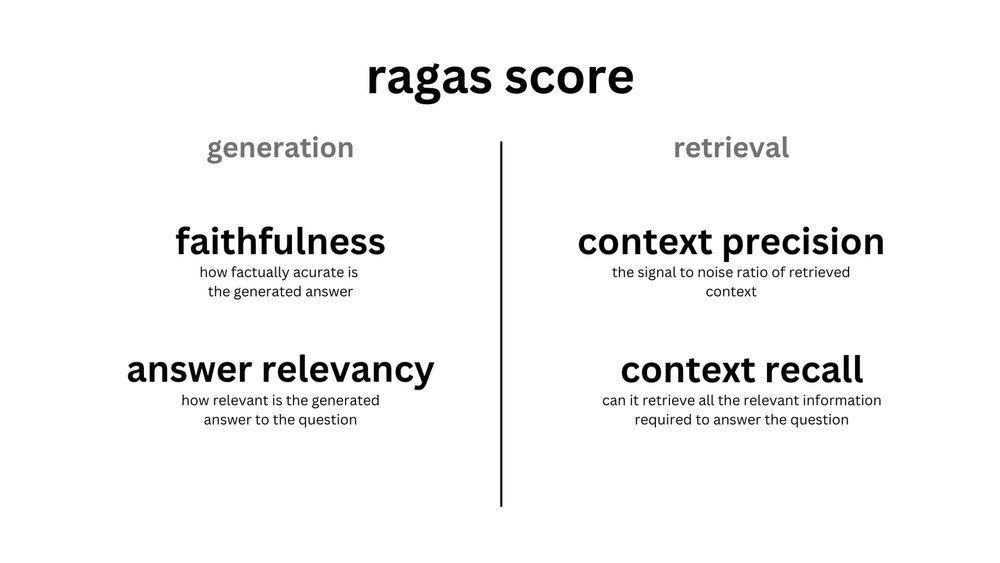

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля
`
`HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

**Промпт для генерации вопросов к виду изображения**

Проводится тестирование RAG по технологии RAGAS.
В файле перечислены документы. Есть поле Описание изображения. Необходимо к этому полю создать Вопрос. Результат сгенерировать как массив вопросов. Всего должно получиться 120 элементов.

Пример вопроса для документа

Как выглядит  Доходный дом купца Чувильдина?

Пример документа

**Индекс: 0**
**Название:** Доходный дом купца Чувильдина
**Тип объекта:** Дом
**Локация:** Город Екатеринбург, Россия
**Координаты:** 60.607727, 56.832176
**Описание:** Дом купца Чувильдина
**Описание изображения:** большое здание с часами наверху
**Идентификатор во внешней БД:** Wikidata (Q27921892)

In [102]:
def data_preprocess(df=None):
    questions = [
        "Как выглядит Доходный дом купца Чувильдина?",
        "Как выглядит Дом В.И. Чувильдина?",
        "Как выглядит Дом Актёра?",
        "Как выглядит Уральский геологический музей?",
        "Как выглядит Музей истории Екатеринбурга?",
        "Как выглядит Дом Метенкова?",
        "Как выглядит Театр оперы и балета?",
        "Как выглядит Театр кукол?",
        "Как выглядит Театр музыкальной комедии?",
        "Как выглядит Харитоновский сад?", "Как выглядит Храм-на-Крови?",
        "Как выглядит Храм на Крови?", "Как выглядит Свято-Никольский храм?",
        "Как выглядит Успенский собор на ВИЗе?",
        "Как выглядит Свято-Троицкий Кафедральный собор?",
        "Как выглядит Александро-Невский собор?",
        "Как выглядит памятник Серго Орджоникидзе?",
        "Как выглядит памятник Комсомолу Урала?",
        "Как выглядит памятник Ленину?", "Как выглядит Царский мост?",
        "Как выглядит Каменный мост?",
        "Как выглядит здание бывшей гостиницы \"Мадрид\"?",
        "Как выглядит Центральный стадион?",
        "Как выглядит Преображенская церковь на Уктусе?",
        "Как выглядит Иоанно-Предтеченский Кафедральный собор?",
        "Как выглядит Усадьба Железнова?", "Как выглядит Усадьба Тарасова?",
        "Как выглядит Ново-Тихвинский монастырь?",
        "Как выглядит улица Февральской Революции?",
        "Как выглядит улица Добролюбова?",
        "Как выглядит Уральский государственный университет имени А. М. Горького?",
        "Как выглядит Уральский государственный технический университет?",
        "Как выглядит торговый дом Скоба?", "Как выглядит Дом Виноградовых?",
        "Как выглядит Доходный дом купчихи П. Е. Кубаревой?",
        "Как выглядит Дом М. В. Медведева?",
        "Как выглядит Памятник жертвам и мученикам революции 1905 года?",
        "Как выглядит Шахматный дом (Игорный дом А.И. Троицкого)?",
        "Как выглядит Обелиск Минину и Пожарскому?",
        "Как выглядит Северная башня?", "Как выглядит Борисоглебская башня?",
        "Как выглядит Белая башня?", "Как выглядит кинотеатр «Рекорд»?",
        "Как выглядит Театр оперы и балета в Нижнем Новгороде?",
        "Как выглядит Нижегородский государственный академический театр драмы им. М. Горького?",
        "Как выглядит Собор Александра Невского?",
        "Как выглядит Спасский староярмарочный кафедральный собор?",
        "Как выглядит Нижегородская соборная мечеть?",
        "Как выглядит Нижегородский государственный художественный музей?",
        "Как выглядит Усадьба Добролюбовых?",
        "Как выглядит Дом-музей Добролюбова?",
        "Как выглядит Автозаводский парк культуры и отдыха?",
        "Как выглядит Сормовский парк?", "Как выглядит Парк имени Кулибина?",
        "Как выглядит Церковь во имя Всемилостивейшего Спаса?",
        "Как выглядит Церковь во имя Всемирлостивейшего Спаса?",
        "Как выглядит Храм святителей Московских?",
        "Как выглядит Церковь Знамения Божией Матери и святых Жен-Мироносиц?",
        "Как выглядит Церковь Александра Невского в Сормово?",
        "Как выглядит Спасо-преображенская церковь?",
        "Как выглядит Благовещенский монастырь?",
        "Как выглядит Благовещенский собор?",
        "Как выглядит Печёрский Вознесенский монастырь?",
        "Как выглядит Усадьба Рукавишниковых?",
        "Как выглядит Усадьба Е. И. Богоявленской?",
        "Как выглядит Усадьба Киршбаумов?", "Как выглядит стадион «Локомотив»?",
        "Как выглядит Церковь Никиты Великомученика?",
        "Как выглядит Троицкая церковь?",
        "Как выглядит Армянская церковь Владимира?",
        "Как выглядит Собор Успения Пресвятой Богородицы?",
        "Как выглядит Исторический музей во Владимире?",
        "Как выглядит Музей ложки?",
        "Как выглядит Владимиро-Суздальский музей-заповедник?",
        "Как выглядит Дом-музей Столетовых?",
        "Как выглядит Храм Казанской иконы Божией Матери?",
        "Как выглядит Костел Святого Розария Пресвятой Девы Марии?",
        "Как выглядит Дмитриевский собор?",
        "Как выглядит Князь-Владимирская церковь?",
        "Как выглядит Владимирский академический областной драматический театр?",
        "Как выглядит Богородице-Рождественский мужской монастырь?",
        "Как выглядит Успенский Княгинин монастырь?",
        "Как выглядит Золотые ворота?",
        "Как выглядит памятник \"Белокаменные памятники Владимира и Суздаля\"?",
        "Как выглядит Владимирский государственный гуманитарный университет?",
        "Как выглядит Владимирский планетарий?",
        "Как выглядит памятник природы \"Лесной парк Дружба\"?",
        "Как выглядит Церковь Рождества Христова в Ярославле?",
        "Как выглядит церковь Иоанна Предтечи в Толчкове?",
        "Как выглядит церковь Михаила Архангела?",
        "Как выглядит Крестоборогодская церковь?",
        "Как выглядит Церковь Рождества Христова?",
        "Как выглядит Храм Архангела Михаила?",
        "Как выглядит Губернаторский дом в Ярославле?",
        "Как выглядит Владимирская церковь?",
        "Как выглядит Мемориальный дом-музей М. Богдановича?",
        "Как выглядит Власьевская (Знаменская) башня?",
        "Как выглядит Знаменская церковь?", "Как выглядит Волжская башня?",
        "Как выглядит Демидовский сад?", "Как выглядит Власьевский сквер?",
        "Как выглядит памятник М.В. Фрунзе?",
        "Как выглядит памятник Фёдору Ивановичу Толбухину?",
        "Как выглядит Памятник Леониду Николаевичу Трефолеву?",
        "Как выглядит Казанский женский монастырь?",
        "Как выглядит Николо-Сковородский монастырь?",
        "Как выглядит Петровский монастырь?",
        "Как выглядит мост Волжские Ворота?",
        "Как выглядит Музей истории города Ярославля?",
        "Как выглядит Ярославский музей-заповедник?",
        "Как выглядит Ярославский художественный музей?",
        "Как выглядит Парк 1000-летия Ярославля?",
        "Как выглядит Парк на Стрелке?",
        "Как выглядит Театр кукол в Ярославле?",
        "Как выглядит Российский государственный академический театр драмы имени Федора Волкова?",
        "Как выглядит Успенский собор?",
        "Как выглядит Ярославская соборная мечеть?",
        "Как выглядит Ярославский цирк?", "Как выглядит Ярославский зоопарк?",
        "Как выглядит Дмитриевская башня?"]
    df['question'] = questions
    # print(len(questions))

    return 0

In [103]:
data_preprocess()

120


0

In [ ]:
def answer_relevancy(...):
    # your code here
    return ...

# Протестируйте ваш RAG (3 балла)

In [ ]:
# your code here

# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [ ]:
# your code here